# Tomato shoot-apex snRNA-seq atlas — trichome developmental and glandular metabolic marker programs

**Dataset:** E-ENAD-53 (*Solanum lycopersicum* cv. M82 shoot apex, 10x Genomics snRNA-seq;
Tian et al. 2020, bioRxiv https://doi.org/10.1101/2020.09.20.305029)
**Scope:** Early shoot apex + leaf primordia (P0–P3); ~12,000 nuclei; 21,402 genes detected.

## Biological question

Does this early shoot-apex atlas capture trichome developmental and glandular programs,
and can partial Type IV acylsugar or Type VI terpene metabolic marker states be resolved
within atlas-defined trichome nuclei?

## Critical technical note — single-nucleus vs single-cell RNA-seq

> ⚠️ **This dataset is single-nucleus RNA-seq (snRNA-seq), not scRNA-seq.**
> Nuclear transcripts are profiled, not whole-cell transcriptomes.
> Metabolic enzyme genes — including acylsugar transferases (ASAT2, AECH1) and
> terpene synthases (EOT1, EOT2, TPS9) — are predominantly translated in the
> **cytoplasm** and their transcripts are underrepresented in nuclear preparations
> relative to whole-cell protocols (Ding et al. 2020, *Nature Biotechnology*,
> https://doi.org/10.1038/s41587-020-0465-8).
> Weak Type IV and Type VI metabolic module scores in this atlas therefore reflect
> **both** the early developmental stage of the tissue **and** this systematic
> nuclear capture bias. Results should be interpreted as developmental context
> and candidate prioritisation, not as a quantitative measure of metabolic output.

## Analytical strategy

Six literature-backed marker modules were defined:

| # | Module | Biological focus |
|---|--------|-----------------|
| 1 | Epidermal identity | ML1, PDF1, CD2, SVB, Wo — L1-layer and proto-epidermal fate |
| 2 | Trichome morphogenesis | WOX3b, MX1/MIXTA, MTR2/CycB3, MTR3, HAIR, Hairless — morphogenesis TFs |
| 3 | Glandular regulation | Glandless, GCR1, GCR2, TOE1B, LFS — gland-fate and GCR regulators |
| 4 | Type IV acylsugar metabolism | AACS1, AECH1, ABC Transporter, ASAT2, ASH3 — short-chain acylsugar pathway |
| 5 | Type VI terpene metabolism | EOT1, EOT2, MCPI, TPS9 — sesquiterpene/monoterpene biosynthesis |
| 6 | Reference control | Photosynthesis (RBCS-1, CAB13, PSBO/B/R) and cell-cycle (Cyclin B2, WEE1, Histone H4) |

## Key findings (summary)

- Trichome morphogenesis and glandular regulation modules are robustly enriched in atlas-defined trichome nuclei.
- Epidermal identity co-enriches with trichome cells, consistent with trichomes being epidermal derivatives.
- Type IV acylsugar and Type VI terpene metabolic markers are detected in only a subset of trichome nuclei (~11.8 % Type IV-like, ~17.7 % Type VI-like, ~3.5 % mixed).
- ~67 % of trichome nuclei are metabolic-marker-negative, consistent with early developmental stage and nuclear capture bias (see note above).
- No clean Type IV vs Type VI subtype separation is recovered; the data show partial marker-program states.

## Repository structure

```
.
├── 01_github_summary_tomato_trichome_atlas.ipynb   ← this notebook (Python)
├── ggPlantMap_00_prepare_roi.R                     ← ROI construction (R)
├── ggPlantMap_01_final_figures.R                   ← spatial figures (R)
├── data/
│   ├── E-ENAD-53.project.h5ad                     ← atlas (download separately)
│   └── curated_gene_modules_github_final.csv       ← curated marker table
├── figures/                                        ← output figures
└── tables/                                         ← output summary tables
```

## References

- Tian et al. (2020). *Single-nucleus RNA-seq resolves spatiotemporal developmental trajectories in the tomato shoot apex.* bioRxiv. https://doi.org/10.1101/2020.09.20.305029
- Ding et al. (2020). *Systematic comparison of single-cell and single-nucleus RNA-sequencing methods.* Nature Biotechnology, 38, 737–746. https://doi.org/10.1038/s41587-020-0465-8
- Jo & Kajala (2024). ggPlantmap: An open-source R package for informative ggplot maps from plant images. *J. Exp. Bot.* 75(17), 5366–5376. https://doi.org/10.1093/jxb/erae043


---
## 0 — Environment setup

All imports, path configuration, and shared helper functions are defined here. Run this cell before any other section.

**Input files:** keep these in the same folder as this notebook:
- `E-ENAD-53.project.h5ad` — tomato shoot-apex atlas (`.h5ad`)
- `curated_gene_modules_github.csv` — restored final marker-module table

**Outputs** are written to:
- `tables/` for CSV summaries
- `figures/` for exported plots
- `data/` only for ggPlantMap export files, so the R scripts can find them easily

In [22]:
# ============================================================
# 0 — Setup
# ============================================================

from pathlib import Path
import re
from collections import OrderedDict

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt

from scipy.stats import fisher_exact, mannwhitneyu
from statsmodels.stats.multitest import multipletests
from IPython.display import display, HTML, Markdown, Image

pd.set_option("display.max_columns", 120)

# ------------------------------------------------------------
# File paths
# ------------------------------------------------------------
# Keep the atlas file and curated module CSV in the same folder
# as this notebook. Output tables/figures are written separately.

BASE_DIR = Path(".")
DATA_DIR = BASE_DIR                  # input files live beside the notebook
TABLE_DIR = Path("tables")
FIG_DIR = Path("figures")
GGPLANTMAP_DIR = Path("data")        # export files for R/ggPlantMap

TABLE_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)
GGPLANTMAP_DIR.mkdir(exist_ok=True)

ATLAS_FILE = DATA_DIR / "E-ENAD-53.project.h5ad"
GENE_MODULE_FILE = DATA_DIR / "curated_gene_modules_github.csv"

print("Notebook folder:", BASE_DIR.resolve())
print("Atlas file found:", ATLAS_FILE.exists(), ATLAS_FILE)
print("Module CSV found:", GENE_MODULE_FILE.exists(), GENE_MODULE_FILE)

if not ATLAS_FILE.exists():
    raise FileNotFoundError(f"Missing atlas file: {ATLAS_FILE.resolve()}")

if not GENE_MODULE_FILE.exists():
    raise FileNotFoundError(f"Missing module CSV: {GENE_MODULE_FILE.resolve()}")

# ------------------------------------------------------------
# Final restored module order and labels
# ------------------------------------------------------------

FINAL_MODULE_ORDER = [
    "epidermal_identity",
    "trichome_morphogenesis",
    "glandular_regulation",
    "typeIV_acylsugar_metabolism",
    "typeVI_terpene_metabolism",
    "reference_control",
]

MODULE_LABELS = OrderedDict({
    "epidermal_identity": "Epidermal identity",
    "trichome_morphogenesis": "Trichome morphogenesis",
    "glandular_regulation": "Glandular regulation",
    "typeIV_acylsugar_metabolism": "Type IV acylsugar metabolism",
    "typeVI_terpene_metabolism": "Type VI terpene metabolism",
    "reference_control": "Reference control",
})

FINE_CONTEXT_ORDER = [
    "meristem",
    "epidermis-early",
    "epidermis-late",
    "trichome cell",
    "subepidermis-abaxial",
    "mesophyll-adaxial",
    "mesophyll-abaxial",
    "vascular leaf-1",
    "vascular leaf-2",
    "other_or_unassigned",
]

# Backward-compatible alias for older cells.
FINE_CONTEXT_ORDER_BASE = FINE_CONTEXT_ORDER

# ------------------------------------------------------------
# Helper functions
# ------------------------------------------------------------

def clean_solyc(value):
    """Return Solyc ID without version suffix."""
    if pd.isna(value):
        return np.nan
    match = re.search(r"Solyc\d+g\d+(?:\.\d+)?", str(value))
    if match is None:
        return np.nan
    return re.sub(r"\.\d+$", "", match.group(0))


def get_expression_df(adata_obj, gene_ids, layer=None):
    """Extract expression for genes present in the atlas."""
    gene_ids = [
        g for g in pd.Series(gene_ids).dropna().drop_duplicates().tolist()
        if g in adata_obj.var_names
    ]
    if len(gene_ids) == 0:
        return pd.DataFrame(index=adata_obj.obs_names)
    return sc.get.obs_df(adata_obj, keys=gene_ids, layer=layer)


def zscore_columns(df):
    """Z-score each column independently."""
    return df.apply(lambda col: (col - col.mean()) / (col.std() + 1e-9), axis=0)


def save_current_figure(filename, dpi=300):
    """Save current matplotlib figure into figures/."""
    path = FIG_DIR / filename
    plt.savefig(path, dpi=dpi, bbox_inches="tight", facecolor="white")
    print(f"Saved: {path}")


def bh_fdr(pvalues):
    """Benjamini-Hochberg FDR correction."""
    pvalues = pd.Series(pvalues).astype(float)
    valid = pvalues.notna()
    out = pd.Series(np.nan, index=pvalues.index)
    if valid.sum() > 0:
        out.loc[valid] = multipletests(pvalues.loc[valid], method="fdr_bh")[1]
    return out.values


def fisher_enrichment(group_mask, feature_mask, group_name, feature_name):
    """One-sided Fisher enrichment test for a binary feature in a group."""
    group_mask = pd.Series(group_mask).astype(bool)
    feature_mask = pd.Series(feature_mask).astype(bool)

    a = int((group_mask & feature_mask).sum())
    b = int((group_mask & ~feature_mask).sum())
    c = int((~group_mask & feature_mask).sum())
    d = int((~group_mask & ~feature_mask).sum())

    odds_ratio, pvalue = fisher_exact([[a, b], [c, d]], alternative="greater")

    return {
        "group": group_name,
        "feature": feature_name,
        "group_positive": a,
        "group_negative": b,
        "outside_positive": c,
        "outside_negative": d,
        "group_fraction_positive": a / max(a + b, 1),
        "outside_fraction_positive": c / max(c + d, 1),
        "odds_ratio": odds_ratio,
        "pvalue": pvalue,
    }


def wilcoxon_summary(values, group_mask, module_name, comparison_name="trichome_vs_rest"):
    """Mann-Whitney/Wilcoxon rank-sum summary for module scores."""
    values = pd.Series(values).astype(float)
    group_mask = pd.Series(group_mask, index=values.index).astype(bool)

    x = values[group_mask].dropna()
    y = values[~group_mask].dropna()

    if len(x) == 0 or len(y) == 0:
        u_stat = np.nan
        pvalue = np.nan
        rank_biserial = np.nan
    else:
        u_stat, pvalue = mannwhitneyu(x, y, alternative="two-sided")
        rank_biserial = (2 * u_stat / (len(x) * len(y))) - 1

    return {
        "module": module_name,
        "comparison": comparison_name,
        "n_group": len(x),
        "n_outside": len(y),
        "mean_group": x.mean() if len(x) else np.nan,
        "mean_outside": y.mean() if len(y) else np.nan,
        "mean_difference": (x.mean() - y.mean()) if len(x) and len(y) else np.nan,
        "median_group": x.median() if len(x) else np.nan,
        "median_outside": y.median() if len(y) else np.nan,
        "median_difference": (x.median() - y.median()) if len(x) and len(y) else np.nan,
        "rank_biserial_effect_size": rank_biserial,
        "pvalue": pvalue,
    }

Notebook folder: C:\Users\fforn\tomato_atlas\GitHub\Final666
Atlas file found: True E-ENAD-53.project.h5ad
Module CSV found: True curated_gene_modules_github.csv


---
## 1 — Load atlas and marker-gene table

The atlas h5ad contains author-provided cell-type annotations in `obs['authors_cell_type']`.
No re-clustering or differential expression is performed; all cell identities are inherited
from Tian et al. (2020). The normalised expression layer is used throughout.

In [23]:
adata = sc.read_h5ad(ATLAS_FILE)
gene_modules_raw = pd.read_csv(GENE_MODULE_FILE)

analysis_layer = "normalised" if "normalised" in adata.layers else None

print(adata)
print("Expression layer used:", analysis_layer if analysis_layer else "adata.X")
print("Marker table rows:", gene_modules_raw.shape[0])
display(gene_modules_raw.head())

AnnData object with n_obs × n_vars = 20278 × 26293
    obs: 'age', 'cultivar', 'developmental_stage', 'genotype', 'growth_condition', 'organism_part', 'organism', 'authors_cell_type_-_ontology_labels', 'authors_cell_type', 'organism_part.1', 'age_ontology', 'cultivar_ontology', 'developmental_stage_ontology', 'genotype_ontology', 'growth_condition_ontology', 'organism_part_ontology', 'organism_ontology', 'authors_cell_type_-_ontology_labels_ontology', 'authors_cell_type_ontology', 'organism_part_ontology.1', 'doublet_score', 'predicted_doublet', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'n_counts', 'n_genes', 'louvain_resolution_0.1', 'louvain_resolution_0.3', 'louvain_resolution_0.5', 'louvain_resolution_0.7', 'louvain_resolution_1.0', 'louvain_resolution_2.0', 'louvain_resolution_3.0', 'louvain_resolution_4.0', 'louvain_resolution_5.0'
    var: 'gene_symbols', 'chromosome', 

,gene_name,display_name,solyc_id,module,module_label,module_order,gene_order,gene_role,functional_role,function_summary,reference_label,notes
0,ML1,ML1,Solyc10g005330,epidermal_identity,Epidermal identity,1,1,HD-Zip IV transcription factor,Epidermal/L1 identity marker,Meristem Layer 1 marker used for epidermal/pro...,Tian et al. 2020; epidermal marker literature,NaN
1,PDF1,PDF1,Solyc07g055950,epidermal_identity,Epidermal identity,1,2,Protodermal factor,Epidermal/protoderm marker,Protodermal factor linked to epidermal identit...,Tian et al. 2020,NaN
2,CD2,CD2,Solyc01g091630,epidermal_identity,Epidermal identity,1,3,HD-Zip IV / cuticle regulator,Epidermal/cuticle context,Cuticle and epidermal regulator used as epider...,Tian et al. 2020; Galdon-Armero 2018; Zocca et...,Same locus also reported as CD2/ANL2 in atlas ...
3,SVB,SVB,Solyc01g100750,epidermal_identity,Epidermal identity,1,4,Epidermis/trichome developmental regulator,Epidermal-trichome GRN node,SMALLER TRICHOMES; atlas epidermis-trichome re...,Tian et al. 2020,NaN
4,WOOLLY / Wo,Wo,Solyc02g080260,epidermal_identity,Epidermal identity,1,5,HD-Zip IV transcription factor,Epidermal-to-trichome competence regulator,Master regulator of trichome initiation and mo...,Tian et al. 2020; Wu et al. 2023; Zocca et al....,Bridge marker; not interpreted as purely epide...


---
## 2 — Map curated marker modules to atlas gene IDs

Marker genes are matched to atlas features by version-stripped Solyc IDs
(e.g. `Solyc01g005000.3.1` → `Solyc01g005000`). This makes the mapping
robust to annotation version differences between the marker table and the atlas.

Unmapped genes are written to `tables/unmapped_gene_modules.csv` for inspection.
The final mapped set is the sole source of module membership used downstream.

In [24]:
gene_modules = gene_modules_raw.copy()

required_columns = [
    "display_name", "solyc_id", "module", "module_label", "module_order",
    "gene_order", "gene_role", "functional_role", "function_summary", "reference_label"
]
missing_required = [c for c in required_columns if c not in gene_modules.columns]
if missing_required:
    raise ValueError(f"Missing required columns in marker table: {missing_required}")

gene_modules["solyc_clean"] = gene_modules["solyc_id"].apply(clean_solyc)

gene_modules["module"] = pd.Categorical(
    gene_modules["module"],
    categories=FINAL_MODULE_ORDER,
    ordered=True,
)
gene_modules = gene_modules[gene_modules["module"].notna()].copy()
gene_modules["module_label"] = gene_modules["module"].astype(str).map(MODULE_LABELS)

gene_modules = gene_modules.sort_values(["module", "gene_order", "display_name"]).reset_index(drop=True)

atlas_genes = adata.var.copy()
atlas_genes["atlas_id"] = atlas_genes.index.astype(str)
atlas_genes["solyc_clean"] = atlas_genes["atlas_id"].apply(clean_solyc)

curated_markers = gene_modules.merge(
    atlas_genes[["atlas_id", "solyc_clean"]].dropna().drop_duplicates("solyc_clean"),
    on="solyc_clean",
    how="left",
)
curated_markers["present_in_atlas"] = curated_markers["atlas_id"].notna()

mapped_markers = curated_markers[curated_markers["present_in_atlas"]].copy()
unmapped_markers = curated_markers[~curated_markers["present_in_atlas"]].copy()

mapped_markers.to_csv(TABLE_DIR / "mapped_gene_modules.csv", index=False)
unmapped_markers.to_csv(TABLE_DIR / "unmapped_gene_modules.csv", index=False)
curated_markers.to_csv(TABLE_DIR / "curated_marker_modules_mapped_to_atlas.csv", index=False)

print(f"Mapped markers: {mapped_markers.shape[0]}")
print(f"Unmapped markers: {unmapped_markers.shape[0]}")
if not unmapped_markers.empty:
    display(unmapped_markers[["display_name", "solyc_id", "module_label"]])

curated_markers = mapped_markers.copy()

final_modules = OrderedDict()
for module_id in FINAL_MODULE_ORDER:
    labels = (
        curated_markers.loc[curated_markers["module"].astype(str).eq(module_id), "display_name"]
        .dropna()
        .tolist()
    )
    final_modules[MODULE_LABELS[module_id]] = labels

display(
    curated_markers[[
        "module_label", "display_name", "solyc_id", "atlas_id",
        "gene_role", "functional_role", "reference_label"
    ]]
)

Mapped markers: 32
Unmapped markers: 0


,module_label,display_name,solyc_id,atlas_id,gene_role,functional_role,reference_label
0,Epidermal identity,ML1,Solyc10g005330,Solyc10g005330.3,HD-Zip IV transcription factor,Epidermal/L1 identity marker,Tian et al. 2020; epidermal marker literature
1,Epidermal identity,PDF1,Solyc07g055950,Solyc07g055950.3,Protodermal factor,Epidermal/protoderm marker,Tian et al. 2020
2,Epidermal identity,CD2,Solyc01g091630,Solyc01g091630.3,HD-Zip IV / cuticle regulator,Epidermal/cuticle context,Tian et al. 2020; Galdon-Armero 2018; Zocca et...
3,Epidermal identity,SVB,Solyc01g100750,Solyc01g100750.2,Epidermis/trichome developmental regulator,Epidermal-trichome GRN node,Tian et al. 2020
4,Epidermal identity,Wo,Solyc02g080260,Solyc02g080260.3,HD-Zip IV transcription factor,Epidermal-to-trichome competence regulator,Tian et al. 2020; Wu et al. 2023; Zocca et al....
5,Trichome morphogenesis,WOX3b,Solyc11g072790,Solyc11g072790.2,WOX transcription factor,Trichome morphogenesis regulator,Tian et al. 2020; Wu et al. 2023; Zocca et al....
6,Trichome morphogenesis,MX1 / MIXTA,Solyc01g010910,Solyc01g010910.2,MYB/MIXTA-like transcription factor,Trichome morphogenesis regulator,Tian et al. 2020; Wu et al. 2023; Galdon-Armer...
7,Trichome morphogenesis,MTR2 / CycB3,Solyc06g073990,Solyc06g073990.2,MTR / cyclin-B3-like regulator,Wo dosage / multicellular trichome regulator,Tian et al. 2020; Wu et al. 2023; Wu et al. 2024
8,Trichome morphogenesis,MTR3,Solyc01g007870,Solyc01g007870.3,MTR / cyclin-like regulator,Trichome morphogenesis regulator,Zocca et al. 2025; Wu et al. 2023
9,Trichome morphogenesis,HAIR,Solyc10g078970,Solyc10g078970.1,C2H2 zinc-finger protein,Trichome development marker,Galdon-Armero 2018


---
## 3 — Curated module overview

Each card below shows the genes in a module, their broad functional role,
a brief interpretation, and the literature source.
This makes the biological assumptions of the analysis fully transparent.

In [25]:
def render_module_cards(markers):
    html = """
    <style>
    .module-grid {display: grid; grid-template-columns: repeat(2, minmax(340px, 1fr)); gap: 14px; margin: 10px 0 18px 0;}
    .module-card {border: 1px solid #ddd; border-radius: 8px; padding: 12px; background: white; color: black;}
    .module-card h4 {margin: 0 0 8px 0; font-size: 15px;}
    .module-card table {border-collapse: collapse; width: 100%; font-size: 11px; line-height: 1.25;}
    .module-card th {text-align: left; border-bottom: 1px solid #ccc; padding: 4px;}
    .module-card td {vertical-align: top; border-bottom: 1px solid #eee; padding: 4px;}
    </style>
    <div class="module-grid">
    """

    for module_id in FINAL_MODULE_ORDER:
        sub = markers[markers["module"].astype(str).eq(module_id)].copy()
        if sub.empty:
            continue
        title = MODULE_LABELS[module_id]
        rows = []
        for _, row in sub.iterrows():
            rows.append(
                f"<tr>"
                f"<td><b>{row['display_name']}</b></td>"
                f"<td>{row.get('gene_role', '')}</td>"
                f"<td>{row.get('function_summary', row.get('functional_role', ''))}</td>"
                f"<td>{row.get('reference_label', '')}</td>"
                f"</tr>"
            )
        html += f"""
        <div class="module-card">
          <h4>{title}</h4>
          <table>
            <thead><tr><th>Gene</th><th>Role</th><th>Function</th><th>Reference</th></tr></thead>
            <tbody>{''.join(rows)}</tbody>
          </table>
        </div>
        """
    html += "</div>"
    return HTML(html)

render_module_cards(curated_markers)

Gene,Role,Function,Reference
ML1,HD-Zip IV transcription factor,Meristem Layer 1 marker used for epidermal/protoderm context.,Tian et al. 2020; epidermal marker literature
PDF1,Protodermal factor,Protodermal factor linked to epidermal identity and the atlas epidermal trajectory.,Tian et al. 2020
CD2,HD-Zip IV / cuticle regulator,Cuticle and epidermal regulator used as epidermal/trichome-context support.,Tian et al. 2020; Galdon-Armero 2018; Zocca et al. 2025
SVB,Epidermis/trichome developmental regulator,SMALLER TRICHOMES; atlas epidermis-trichome regulatory context marker.,Tian et al. 2020
Wo,HD-Zip IV transcription factor,Master regulator of trichome initiation and morphogenesis; kept here as epidermal competence/transition support.,Tian et al. 2020; Wu et al. 2023; Zocca et al. 2025; Galdon-Armero 2018
Gene,Role,Function,Reference
WOX3b,WOX transcription factor,Trichome morphogenesis factor enriched in trichome-labelled nuclei.,Tian et al. 2020; Wu et al. 2023; Zocca et al. 2025
MX1 / MIXTA,MYB/MIXTA-like transcription factor,MIXTA-like Wo downstream factor associated with trichome morphogenesis.,Tian et al. 2020; Wu et al. 2023; Galdon-Armero 2018
MTR2 / CycB3,MTR / cyclin-B3-like regulator,MTR-family regulator of Wo-dependent multicellular trichome development.,Tian et al. 2020; Wu et al. 2023; Wu et al. 2024
MTR3,MTR / cyclin-like regulator,MTR-family regulator associated with multicellular trichome development.,Zocca et al. 2025; Wu et al. 2023


---
## 4 — Atlas fine cell-type contexts

Ten fine cell-type contexts are used (nine named + `other_or_unassigned`),
following Tian et al.'s annotation scheme. Trichome-labelled nuclei are
identified by the author-provided label `trichome cell`; this notebook
does **not** discover trichome cells de novo.

In [26]:
# ============================================================
# 4 — Atlas fine cell-type contexts
# ============================================================

selected_fine_groups = [
    "meristem",
    "epidermis-early",
    "epidermis-late",
    "trichome cell",
    "subepidermis-abaxial",
    "mesophyll-adaxial",
    "mesophyll-abaxial",
    "vascular leaf-1",
    "vascular leaf-2",
]

if "authors_cell_type" in adata.obs.columns:
    adata.obs["fine_focus_group"] = adata.obs["authors_cell_type"].astype(str)
elif "fine_focus_group" in adata.obs.columns:
    adata.obs["fine_focus_group"] = adata.obs["fine_focus_group"].astype(str)
else:
    raise ValueError("Could not find authors_cell_type or fine_focus_group in adata.obs.")

adata.obs.loc[
    ~adata.obs["fine_focus_group"].isin(selected_fine_groups),
    "fine_focus_group"
] = "other_or_unassigned"

fine_context_order = [
    x for x in FINE_CONTEXT_ORDER
    if x in adata.obs["fine_focus_group"].astype(str).unique()
]

fine_context_order_no_other = [
    x for x in fine_context_order
    if x != "other_or_unassigned"
]

fine_summary = (
    adata.obs["fine_focus_group"]
    .value_counts()
    .rename_axis("fine_focus_group")
    .reset_index(name="n_nuclei")
)

fine_summary["fine_focus_group"] = pd.Categorical(
    fine_summary["fine_focus_group"],
    categories=fine_context_order,
    ordered=True
)

fine_summary = fine_summary.sort_values("fine_focus_group").reset_index(drop=True)

fine_summary["used_as_trichome_denominator"] = (
    fine_summary["fine_focus_group"].astype(str).eq("trichome cell")
)

fine_summary.to_csv(TABLE_DIR / "atlas_fine_context_nuclei_counts.csv", index=False)
display(fine_summary)

n_trichome_fine = int(adata.obs["fine_focus_group"].astype(str).eq("trichome cell").sum())
print(f"Author-defined fine trichome cell nuclei used as main denominator: {n_trichome_fine}")

,fine_focus_group,n_nuclei,used_as_trichome_denominator
0,meristem,1207,False
1,epidermis-early,692,False
2,epidermis-late,1611,False
3,trichome cell,515,True
4,subepidermis-abaxial,645,False
5,mesophyll-adaxial,1753,False
6,mesophyll-abaxial,464,False
7,vascular leaf-1,1085,False
8,vascular leaf-2,288,False
9,other_or_unassigned,12018,False


Author-defined fine trichome cell nuclei used as main denominator: 515


---
## 5 — Statistical validation: marker enrichment in trichome nuclei

Two complementary tests confirm that curated markers are enriched in
atlas-defined trichome nuclei before any metabolic classification is attempted:

- **Gene-level Fisher exact tests** (BH-FDR corrected): tests whether each
  individual marker gene is detected more often in trichome nuclei than in all others.
- **Module-level Wilcoxon rank-sum tests** (BH-FDR corrected): tests whether
  the mean module score is significantly higher in trichome nuclei.

Results are saved to `tables/gene_detection_enrichment_in_trichome_nuclei.csv`
and `tables/module_score_trichome_vs_rest_statistics.csv`.

In [27]:
trichome_mask = adata.obs["fine_focus_group"].astype(str).eq("trichome cell")

all_marker_ids = curated_markers["atlas_id"].dropna().drop_duplicates().tolist()
marker_expr = get_expression_df(adata, all_marker_ids, layer=analysis_layer)
marker_detected = marker_expr > 0

gene_enrichment_rows = []
for _, row in curated_markers.iterrows():
    gene_id = row["atlas_id"]
    detected = marker_detected[gene_id].values if gene_id in marker_detected.columns else np.repeat(False, adata.n_obs)
    res = fisher_enrichment(trichome_mask.values, detected, "trichome cell", row["display_name"])
    res.update({"module": row["module"], "module_label": row["module_label"], "display_name": row["display_name"], "atlas_id": gene_id, "solyc_id": row["solyc_id"]})
    gene_enrichment_rows.append(res)

gene_trichome_enrichment = pd.DataFrame(gene_enrichment_rows)
gene_trichome_enrichment["padj_BH"] = bh_fdr(gene_trichome_enrichment["pvalue"])
gene_trichome_enrichment = gene_trichome_enrichment.sort_values(["padj_BH", "pvalue"])
gene_trichome_enrichment.to_csv(TABLE_DIR / "gene_detection_enrichment_in_trichome_nuclei.csv", index=False)

display(gene_trichome_enrichment[["module_label", "display_name", "group_positive", "outside_positive", "group_fraction_positive", "outside_fraction_positive", "odds_ratio", "pvalue", "padj_BH"]].head(30))

,module_label,display_name,group_positive,outside_positive,group_fraction_positive,outside_fraction_positive,odds_ratio,pvalue,padj_BH
8,Trichome morphogenesis,MTR3,339,1682,0.658252,0.085109,20.705393,1.355922e-216,4.338950e-215
13,Glandular regulation,GCR2,100,62,0.194175,0.003137,76.568208,1.510007e-119,2.416011e-118
1,Epidermal identity,PDF1,447,7494,0.867961,0.379193,10.762027,3.891304e-114,4.150724e-113
7,Trichome morphogenesis,MTR2 / CycB3,145,412,0.281553,0.020847,18.406553,1.293873e-107,1.035098e-106
11,Glandular regulation,Glandless,181,875,0.351456,0.044275,11.697957,1.110452e-102,7.106895e-102
12,Glandular regulation,GCR1,84,63,0.163107,0.003188,60.943542,6.298267e-96,3.359076e-95
5,Trichome morphogenesis,WOX3b,86,92,0.166990,0.004655,42.862724,1.221856e-89,5.585629e-89
3,Epidermal identity,SVB,205,1530,0.398058,0.077417,7.880592,2.065525e-86,8.262099e-86
6,Trichome morphogenesis,MX1 / MIXTA,77,89,0.149515,0.004503,38.861475,2.334421e-78,8.300165e-78
2,Epidermal identity,CD2,381,6717,0.739806,0.339878,5.522328,1.557235e-74,4.983152e-74


In [28]:
module_score_cols = []
module_membership_rows = []

for module_id in FINAL_MODULE_ORDER:
    sub = curated_markers[curated_markers["module"].astype(str).eq(module_id)].copy()
    ids = sub["atlas_id"].dropna().drop_duplicates().tolist()
    X = get_expression_df(adata, ids, layer=analysis_layer)
    score_col = f"score__{module_id}"
    module_score_cols.append(score_col)
    adata.obs[score_col] = np.nan if X.shape[1] == 0 else zscore_columns(X).mean(axis=1).values
    for _, row in sub.iterrows():
        module_membership_rows.append({"module": module_id, "module_label": MODULE_LABELS[module_id], "gene_name": row.get("gene_name", row["display_name"]), "display_name": row["display_name"], "atlas_id": row["atlas_id"], "solyc_id": row["solyc_id"]})

module_membership = pd.DataFrame(module_membership_rows)
module_membership.to_csv(TABLE_DIR / "final_module_gene_membership.csv", index=False)

module_stats_rows = []
for module_id in FINAL_MODULE_ORDER:
    score_col = f"score__{module_id}"
    module_stats_rows.append(wilcoxon_summary(adata.obs[score_col], trichome_mask, MODULE_LABELS[module_id], "trichome cell vs all other nuclei"))

module_trichome_stats = pd.DataFrame(module_stats_rows)
module_trichome_stats["padj_BH"] = bh_fdr(module_trichome_stats["pvalue"])
module_trichome_stats.to_csv(TABLE_DIR / "module_score_trichome_vs_rest_statistics.csv", index=False)
display(module_trichome_stats)

,module,comparison,n_group,n_outside,mean_group,mean_outside,mean_difference,median_group,median_outside,median_difference,rank_biserial_effect_size,pvalue,padj_BH
0,Epidermal identity,trichome cell vs all other nuclei,515,19763,0.928296,-0.024190,0.952487,0.650207,-0.216868,0.867075,0.710460,3.357113e-177,6.714226e-177
1,Trichome morphogenesis,trichome cell vs all other nuclei,515,19763,1.088868,-0.028375,1.117242,0.429126,-0.124279,0.553405,0.663158,0.000000e+00,0.000000e+00
2,Glandular regulation,trichome cell vs all other nuclei,515,19763,1.147008,-0.029890,1.176898,0.511369,-0.090873,0.602241,0.588765,0.000000e+00,0.000000e+00
3,Type IV acylsugar metabolism,trichome cell vs all other nuclei,515,19763,0.313424,-0.008167,0.321591,-0.046528,-0.046528,0.000000,0.120256,8.292789e-48,1.243918e-47
4,Type VI terpene metabolism,trichome cell vs all other nuclei,515,19763,0.385891,-0.010056,0.395947,-0.059206,-0.059206,0.000000,0.153212,1.649798e-41,1.979758e-41
5,Reference control,trichome cell vs all other nuclei,515,19763,-0.206825,0.005390,-0.212215,-0.265021,-0.084583,-0.180438,-0.331387,6.788858e-38,6.788858e-38


---
## 5b — Diagnostic: per-gene detection rates for metabolic markers

**Why this matters:** Before interpreting the metabolic marker classification,
we need to confirm that Type IV and Type VI marker genes are genuinely detectable
in this atlas — not simply absent. If a gene has near-zero detection across all
nuclei, it cannot support meaningful classification.

For each metabolic marker gene, the table below shows:
- Detection rate across **all nuclei** in the atlas
- Detection rate within **trichome nuclei** specifically
- Fold enrichment (trichome vs atlas-wide)

Genes with very low atlas-wide detection (< 1%) are flagged. These contribute
little to the classification and should be interpreted with extra caution.


In [29]:
# ── Per-gene detection rate diagnostic (Critique 2) ─────────────────────────
metabolic_modules = ["typeIV_acylsugar_metabolism", "typeVI_terpene_metabolism"]
metabolic_markers = curated_markers[curated_markers["module"].astype(str).isin(metabolic_modules)].copy()

detection_rows = []
n_total = adata.n_obs
n_trichome = int(trichome_mask.sum())

for _, row in metabolic_markers.iterrows():
    gene_id = row["atlas_id"]
    if gene_id not in adata.var_names:
        continue
    expr = get_expression_df(adata, [gene_id], layer=analysis_layer)[gene_id]
    detected_all = (expr > 0).sum()
    detected_tri = (expr[trichome_mask] > 0).sum()
    rate_all = detected_all / n_total
    rate_tri = detected_tri / n_trichome
    fold = rate_tri / rate_all if rate_all > 0 else np.nan
    detection_rows.append({
        "module_label":        row["module_label"],
        "gene":                row["display_name"],
        "detected_all_nuclei": int(detected_all),
        "rate_all (%)":        round(rate_all * 100, 2),
        "detected_trichome":   int(detected_tri),
        "rate_trichome (%)":   round(rate_tri * 100, 2),
        "fold_enrichment":     round(fold, 2) if not np.isnan(fold) else np.nan,
        "low_detection_flag":  rate_all < 0.01,
    })

detection_df = pd.DataFrame(detection_rows)
detection_df.to_csv(TABLE_DIR / "metabolic_marker_gene_detection_rates.csv", index=False)

# Display with flag highlighted
display(HTML("<b>Metabolic marker gene detection rates — flagged genes have &lt;1% atlas-wide detection</b>"))
display(detection_df.style.apply(
    lambda row: ["background-color: #fff3cd" if row["low_detection_flag"] else "" for _ in row],
    axis=1
))


,module_label,gene,detected_all_nuclei,rate_all (%),detected_trichome,rate_trichome (%),fold_enrichment,low_detection_flag
0,Type IV acylsugar metabolism,AACS1,5,0.020000,4,0.780000,31.500000,True
1,Type IV acylsugar metabolism,AECH1,14,0.070000,3,0.580000,8.440000,True
2,Type IV acylsugar metabolism,ABC Transporter,24,0.120000,4,0.780000,6.560000,True
3,Type IV acylsugar metabolism,ASAT2,6,0.030000,2,0.390000,13.120000,True
4,Type IV acylsugar metabolism,ASH3,690,3.400000,75,14.560000,4.280000,False
5,Type VI terpene metabolism,MCPI,1056,5.210000,36,6.990000,1.340000,False
6,Type VI terpene metabolism,EOT1,148,0.730000,68,13.200000,18.090000,True
7,Type VI terpene metabolism,EOT2,50,0.250000,12,2.330000,9.450000,True
8,Type VI terpene metabolism,TPS9,286,1.410000,9,1.750000,1.240000,False


---
## 6 — Figure 1: Module scores across fine atlas contexts

**What this shows:** Mean z-scored expression of each module's genes,
averaged across all nuclei in each fine atlas context.

**Interpretation:**
- Trichome morphogenesis and glandular regulation peak sharply in trichome cell nuclei.
- Epidermal identity is broadly high in epidermal and trichome contexts (expected —
  trichomes are epidermal derivatives).
- Type IV acylsugar and Type VI terpene metabolism show only weak trichome enrichment,
  consistent with both the early developmental stage of the tissue and nuclear capture
  bias inherent to snRNA-seq (see technical note in the overview — Ding et al. 2020).
- Reference control (photosynthesis + cell cycle) is highest in mesophyll and meristem,
  confirming module specificity.

,Epidermal identity,Trichome morphogenesis,Glandular regulation,Type IV acylsugar metabolism,Type VI terpene metabolism,Reference control
fine_focus_group,,,,,,
meristem,-0.129376,-0.076246,-0.049487,-0.030203,-0.045034,-0.095730
epidermis-early,0.522445,0.091758,-0.027652,-0.010647,-0.032525,0.079736
epidermis-late,0.521720,0.105295,-0.017276,0.020858,-0.042490,-0.082502
trichome cell,0.928296,1.088868,1.147008,0.313424,0.385891,-0.206825
subepidermis-abaxial,0.045393,-0.032180,-0.039392,0.008281,-0.034775,0.184890
mesophyll-adaxial,-0.159251,-0.072241,-0.039885,-0.005691,-0.034960,0.191801
mesophyll-abaxial,-0.184588,-0.073987,-0.056682,-0.029491,-0.050441,-0.054614
vascular leaf-1,-0.258459,-0.067241,-0.048957,-0.034953,-0.043995,-0.082949
vascular leaf-2,-0.235331,-0.064235,-0.038215,-0.029689,-0.044466,-0.124708


Saved: figures\Fig1_module_scores_across_fine_contexts.png


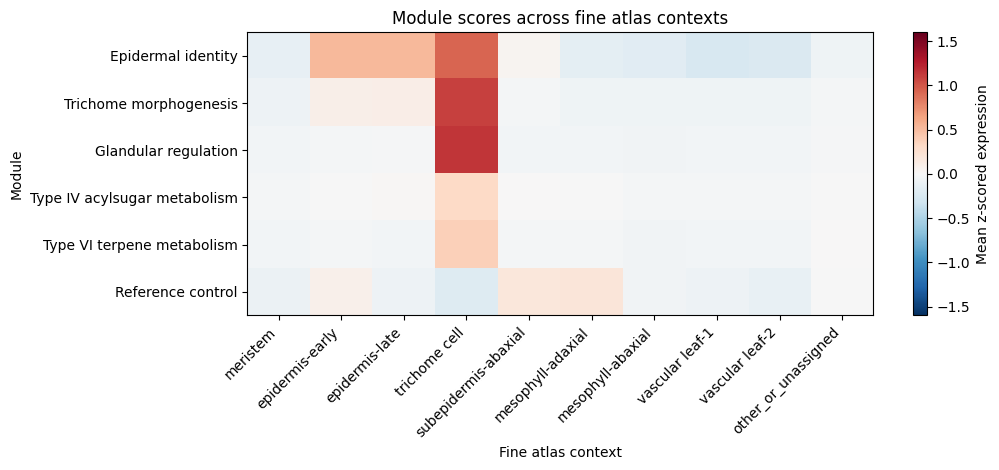

In [30]:
fine_module_scores = adata.obs.groupby("fine_focus_group")[module_score_cols].mean().reindex(fine_context_order)
fine_module_scores.columns = [MODULE_LABELS[col.replace("score__", "")] for col in fine_module_scores.columns]
fine_module_scores.to_csv(TABLE_DIR / "final_module_scores_by_fine_focus_group.csv")
display(fine_module_scores)

plot_matrix = fine_module_scores.T
fig, ax = plt.subplots(figsize=(10.5, 4.8))
im = ax.imshow(plot_matrix.values, aspect="auto", cmap="RdBu_r", vmin=-1.6, vmax=1.6)
ax.set_yticks(np.arange(plot_matrix.shape[0])); ax.set_yticklabels(plot_matrix.index)
ax.set_xticks(np.arange(plot_matrix.shape[1])); ax.set_xticklabels(plot_matrix.columns, rotation=45, ha="right")
ax.set_xlabel("Fine atlas context"); ax.set_ylabel("Module"); ax.set_title("Module scores across fine atlas contexts")
cbar = plt.colorbar(im, ax=ax); cbar.set_label("Mean z-scored expression")
plt.tight_layout(); save_current_figure("Fig1_module_scores_across_fine_contexts.png"); plt.show()

---
## 7 — Figure 2: Gene-level support for module enrichment

**What this shows:** Mean expression per fine atlas context, z-scored per gene
(so each gene's colour scale is independent). This reveals which genes drive
each module score and identifies any outliers within a module.

**Key observations:**
- WOX3b and MX1/MIXTA are the strongest drivers of trichome morphogenesis enrichment.
- Glandless, GCR1 and GCR2 dominate the glandular regulation signal.
- Within Type IV, AACS1, AECH1 and ASAT2 show clearest trichome enrichment;
  ASH3 and ABC Transporter are weaker.
- Within Type VI, EOT1 and EOT2 carry the clearest trichome signal; TPS9 is noisier.
- Hairless (version B) shows a distinctive pattern outside trichome nuclei — a known
  negative regulator of trichome fate, as expected.

Saved: figures\Fig2_gene_level_support_for_module_scores.png


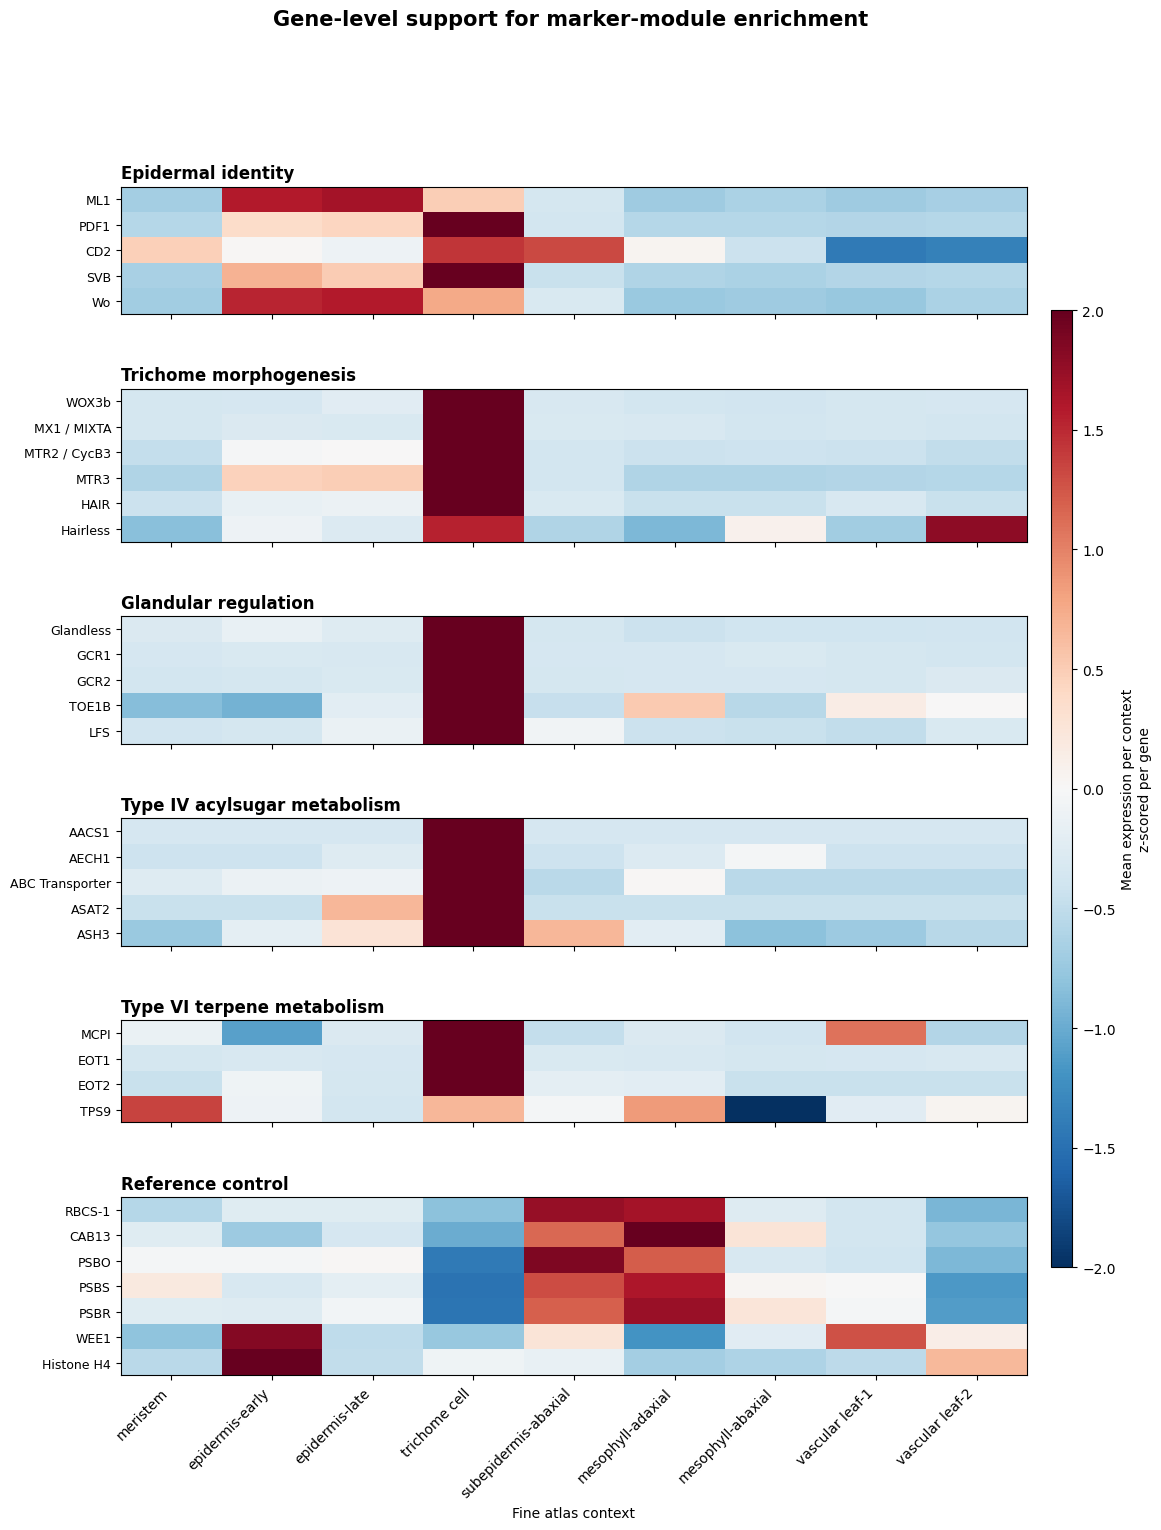

In [31]:
genes_for_expression = curated_markers["atlas_id"].dropna().drop_duplicates().tolist()
X_markers = get_expression_df(adata, genes_for_expression, layer=analysis_layer)
expr_context = X_markers.copy()
expr_context["fine_focus_group"] = adata.obs["fine_focus_group"].astype(str).values
mean_expr_by_context = expr_context.groupby("fine_focus_group")[genes_for_expression].mean().reindex(fine_context_order_no_other)

module_matrices = OrderedDict()
for module_id in FINAL_MODULE_ORDER:
    sub = curated_markers[curated_markers["module"].astype(str).eq(module_id)].sort_values("gene_order")
    ids = sub["atlas_id"].tolist(); labels_for_plot = sub["display_name"].tolist()
    mat = mean_expr_by_context[ids].T; mat.index = labels_for_plot
    mat_z = mat.sub(mat.mean(axis=1), axis=0).div(mat.std(axis=1).replace(0, np.nan), axis=0).fillna(0).clip(-2, 2)
    module_matrices[MODULE_LABELS[module_id]] = mat_z

height_ratios = [max(1.2, mat.shape[0] * 0.42) for mat in module_matrices.values()]
fig_height = sum(height_ratios) + 2.0
fig, axes = plt.subplots(nrows=len(module_matrices), ncols=1, figsize=(12, fig_height), gridspec_kw={"height_ratios": height_ratios}, sharex=True)
if len(module_matrices) == 1: axes = [axes]
for ax, (module_name, mat) in zip(axes, module_matrices.items()):
    im = ax.imshow(mat.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_yticks(np.arange(mat.shape[0])); ax.set_yticklabels(mat.index, fontsize=9)
    ax.set_title(module_name, loc="left", fontsize=12, fontweight="bold")
axes[-1].set_xticks(np.arange(len(fine_context_order_no_other))); axes[-1].set_xticklabels(fine_context_order_no_other, rotation=45, ha="right")
axes[-1].set_xlabel("Fine atlas context")
fig.suptitle("Gene-level support for marker-module enrichment", fontsize=15, fontweight="bold", y=0.995)
fig.subplots_adjust(right=0.88, hspace=0.55)
cbar_ax = fig.add_axes([0.90, 0.18, 0.018, 0.62]); cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Mean expression per context\nz-scored per gene")
save_current_figure("Fig2_gene_level_support_for_module_scores.png"); plt.show()

---
## 8 — Metabolic marker-state classification of trichome nuclei

Each nucleus is assigned a rule-based metabolic marker state using only the
Type IV acylsugar and Type VI terpene metabolism gene sets:

| Class | Rule |
|-------|------|
| **Metabolic-marker-negative** | No Type IV or Type VI marker detected |
| **Type IV acylsugar-marker** | ≥1 Type IV marker detected; no Type VI |
| **Type VI terpene-marker** | ≥1 Type VI marker detected; no Type IV |
| **Mixed-glandular metabolic** | ≥1 marker from both Type IV and Type VI |

Detection threshold: raw expression > 0 (any count in the normalised layer).
Developmental (morphogenesis, glandular regulation) markers are **not** used
to assign classes; they are only used later to characterise the resulting classes.

See Section 8b for a library-size QC check and Section 8c for a sensitivity
analysis across stricter detection thresholds.

In [32]:
typeIV_module = "typeIV_acylsugar_metabolism"
typeVI_module = "typeVI_terpene_metabolism"
typeIV_ids = curated_markers.loc[curated_markers["module"].astype(str).eq(typeIV_module), "atlas_id"].tolist()
typeVI_ids = curated_markers.loc[curated_markers["module"].astype(str).eq(typeVI_module), "atlas_id"].tolist()
classification_ids = sorted(set(typeIV_ids + typeVI_ids))
classification_expr = get_expression_df(adata, classification_ids, layer=analysis_layer)
classification_detected = classification_expr > 0
class_df = adata.obs[["fine_focus_group"]].copy(); class_df["fine_focus_group"] = class_df["fine_focus_group"].astype(str)
class_df["n_typeIV_markers_detected"] = classification_detected[typeIV_ids].sum(axis=1).values
class_df["n_typeVI_markers_detected"] = classification_detected[typeVI_ids].sum(axis=1).values
class_df["has_typeIV_signal"] = class_df["n_typeIV_markers_detected"] >= 1
class_df["has_typeVI_signal"] = class_df["n_typeVI_markers_detected"] >= 1
marker_class_order = ["Metabolic-marker-negative", "Type IV acylsugar-marker", "Type VI terpene-marker", "Mixed-glandular metabolic"]
conditions = [(~class_df["has_typeIV_signal"]) & (~class_df["has_typeVI_signal"]), (class_df["has_typeIV_signal"]) & (~class_df["has_typeVI_signal"]), (~class_df["has_typeIV_signal"]) & (class_df["has_typeVI_signal"]), (class_df["has_typeIV_signal"]) & (class_df["has_typeVI_signal"])]
class_df["marker_class"] = np.select(conditions, marker_class_order, default="unclassified")
class_df["marker_class"] = pd.Categorical(class_df["marker_class"], categories=marker_class_order, ordered=True)
class_df.to_csv(TABLE_DIR / "typeIV_typeVI_metabolic_marker_classes_per_nucleus.csv", index=True)
display(class_df["marker_class"].value_counts(sort=False).rename_axis("marker_class").reset_index(name="n_nuclei"))

,marker_class,n_nuclei
0,Metabolic-marker-negative,18237
1,Type IV acylsugar-marker,634
2,Type VI terpene-marker,1318
3,Mixed-glandular metabolic,89


---
## 8b — Quality control: library size across metabolic marker classes

**Why this matters:** If Type IV-like or Type VI-like trichome nuclei have
systematically higher total counts or more genes detected than marker-negative
nuclei, the classification may partly reflect library quality rather than
genuine metabolic marker expression — a common confound in single-cell data.

The plot below checks `n_genes_by_counts` and `total_counts` distributions
across the four marker classes within trichome-labelled nuclei only.
If distributions are similar, the classification is not driven by library size.


Saved: figures\QC_library_size_by_marker_class.png


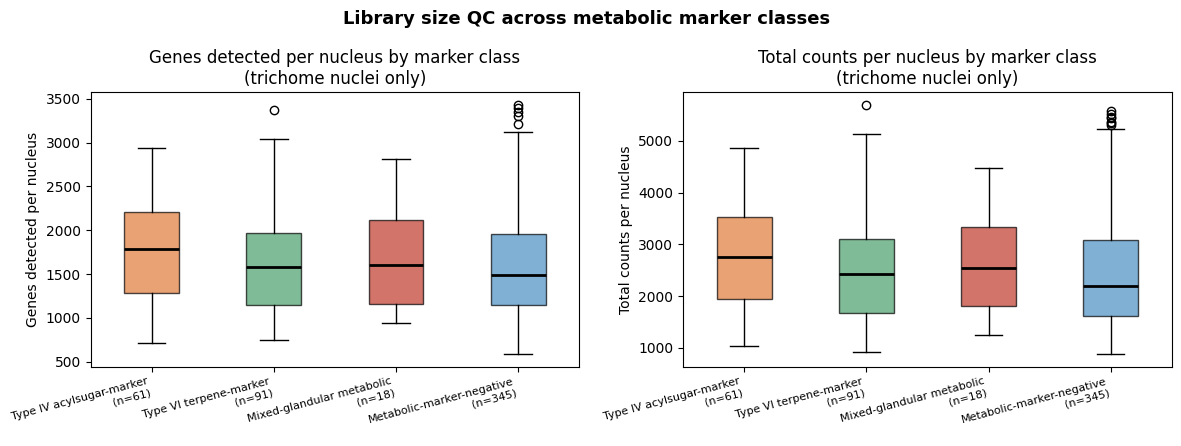

If distributions are similar across classes, classification is not driven by library size.


In [33]:
# ── Library size QC within trichome nuclei (Critique 5) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

trichome_obs = adata.obs.loc[trichome_mask].copy()
trichome_obs["marker_class"] = class_df.loc[trichome_mask, "marker_class"].astype(str).values

class_order_qc = [
    "Type IV acylsugar-marker",
    "Type VI terpene-marker",
    "Mixed-glandular metabolic",
    "Metabolic-marker-negative",
]
colors_qc = ["#e07b39", "#4a9e6b", "#c0392b", "#4a90c4"]

for ax, metric, label in zip(
    axes,
    ["n_genes_by_counts", "total_counts"],
    ["Genes detected per nucleus", "Total counts per nucleus"],
):
    if metric not in trichome_obs.columns:
        ax.set_title(f"{label}\n(not available in adata.obs)")
        continue
    data_by_class = [
        trichome_obs.loc[trichome_obs["marker_class"] == cls, metric].dropna().values
        for cls in class_order_qc
    ]
    bp = ax.boxplot(data_by_class, patch_artist=True, notch=False,
                    medianprops=dict(color="black", linewidth=2))
    for patch, color in zip(bp["boxes"], colors_qc):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ns = [len(d) for d in data_by_class]
    ax.set_xticks(range(1, len(class_order_qc) + 1))
    ax.set_xticklabels(
        [f"{cls}\n(n={n})" for cls, n in zip(class_order_qc, ns)],
        fontsize=8, rotation=15, ha="right"
    )
    ax.set_ylabel(label)
    ax.set_title(f"{label} by marker class\n(trichome nuclei only)")

fig.suptitle("Library size QC across metabolic marker classes", fontsize=13, fontweight="bold")
plt.tight_layout()
save_current_figure("QC_library_size_by_marker_class.png")
plt.show()
print("If distributions are similar across classes, classification is not driven by library size.")


"Library size (genes detected and total counts per nucleus) does not differ systematically across metabolic marker classes within trichome nuclei, confirming that the classification is not driven by differences in nuclear capture quality."

---
## 8c — Sensitivity analysis: classification robustness across detection thresholds

**Why this matters:** The binary detection threshold (expression > 0) is the
simplest possible rule but also the most sensitive to noise and ambient RNA
in snRNA-seq data. Here we re-run the classification at three thresholds
and compare how class proportions change within trichome nuclei:

| Threshold | Rule |
|-----------|------|
| **T1 (current)** | ≥ 1 marker gene detected (expression > 0) |
| **T2 (stricter)** | ≥ 2 marker genes detected |
| **T3 (strictest)** | ≥ 2 marker genes detected, each with > 1 count |

If class proportions are stable across thresholds, the classification is robust.
If they collapse under T2 or T3, the signal is fragile and driven by sparse detection.


Saved: figures\QC_sensitivity_analysis_thresholds.png


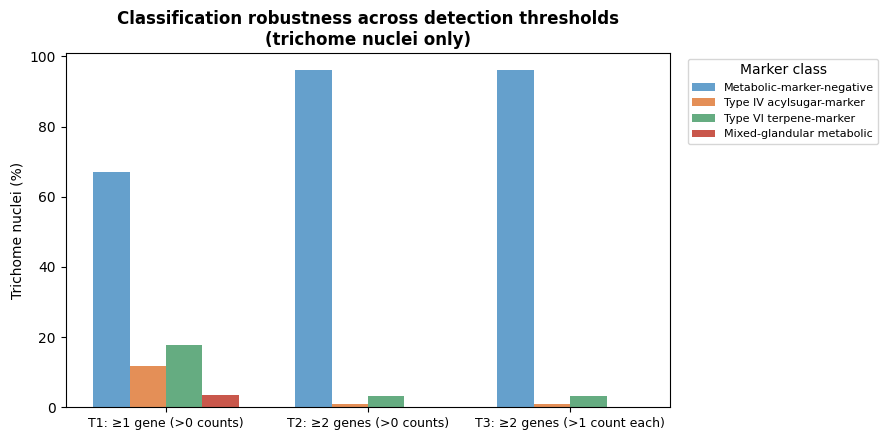

marker_class,Metabolic-marker-negative,Type IV acylsugar-marker,Type VI terpene-marker,Mixed-glandular metabolic
threshold,,,,
T1: ≥1 gene (>0 counts),67.0,11.8,17.7,3.5
T2: ≥2 genes (>0 counts),96.1,0.8,3.1,0.0
T3: ≥2 genes (>1 count each),96.1,0.8,3.1,0.0


In [34]:
# ── Sensitivity analysis: classification at three thresholds (Critique 1) ────
typeIV_ids_s = curated_markers.loc[
    curated_markers["module"].astype(str).eq("typeIV_acylsugar_metabolism"), "atlas_id"
].tolist()
typeVI_ids_s = curated_markers.loc[
    curated_markers["module"].astype(str).eq("typeVI_terpene_metabolism"), "atlas_id"
].tolist()

all_ids_s = sorted(set(typeIV_ids_s + typeVI_ids_s))
expr_s = get_expression_df(adata, all_ids_s, layer=analysis_layer)

# T1: ≥1 gene detected (expression > 0)  — current method
det_t1 = expr_s > 0

# T2: ≥2 genes detected (expression > 0)
det_t2 = expr_s > 0

# T3: ≥2 genes detected with > 1 count
det_t3 = expr_s > 1

def classify_nuclei(det_iv, det_vi, min_genes):
    has_iv = det_iv[typeIV_ids_s].sum(axis=1) >= min_genes
    has_vi = det_vi[typeVI_ids_s].sum(axis=1) >= min_genes
    conditions = [
        (~has_iv) & (~has_vi),
        ( has_iv) & (~has_vi),
        (~has_iv) & ( has_vi),
        ( has_iv) & ( has_vi),
    ]
    return np.select(conditions, marker_class_order, default="unclassified")

results = {}
results["T1: ≥1 gene (>0 counts)"]       = classify_nuclei(det_t1, det_t1, min_genes=1)
results["T2: ≥2 genes (>0 counts)"]      = classify_nuclei(det_t2, det_t2, min_genes=2)
results["T3: ≥2 genes (>1 count each)"]  = classify_nuclei(det_t3, det_t3, min_genes=2)

# Summarise within trichome nuclei
summary_rows = []
for threshold_label, classes in results.items():
    tri_classes = classes[trichome_mask.values]
    total = len(tri_classes)
    for cls in marker_class_order:
        n = (tri_classes == cls).sum()
        summary_rows.append({
            "threshold": threshold_label,
            "marker_class": cls,
            "n": int(n),
            "pct": round(100 * n / total, 1),
        })

sensitivity_df = pd.DataFrame(summary_rows)
sensitivity_df.to_csv(TABLE_DIR / "sensitivity_analysis_classification_thresholds.csv", index=False)

# Plot
pivot = sensitivity_df.pivot(index="threshold", columns="marker_class", values="pct")[marker_class_order]
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(pivot))
width = 0.18
colors_sens = ["#4a90c4", "#e07b39", "#4a9e6b", "#c0392b"]
for i, (cls, color) in enumerate(zip(marker_class_order, colors_sens)):
    ax.bar(x + i * width, pivot[cls].values, width, label=cls, color=color, alpha=0.85)
ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(pivot.index, fontsize=9)
ax.set_ylabel("Trichome nuclei (%)")
ax.set_title("Classification robustness across detection thresholds\n(trichome nuclei only)",
             fontweight="bold")
ax.legend(title="Marker class", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
save_current_figure("QC_sensitivity_analysis_thresholds.png")
plt.show()
display(pivot.round(1))


The Type IV acylsugar marker classification is sensitive to threshold choice and should be interpreted as sparse single-gene detection rather than a robust metabolic program.

---
## 9 — Figure 3: Metabolic marker-state distribution across fine atlas contexts

**What this shows:** Stacked percentage bars; n per context shown above each bar.

**Interpretation:**
- Trichome cell nuclei have the highest proportion of Type IV-like (~11.8 %),
  Type VI-like (~17.7 %) and mixed (~3.5 %) nuclei of any context.
- All other contexts are ≥90 % metabolic-marker-negative.
- Subepidermis-abaxial shows a modest Type VI-like signal (~8 %), which may
  reflect proximity to trichome-rich surface tissue.
- The dominant class even in trichome nuclei remains metabolic-marker-negative
  (~67 %), consistent with early developmental stage and nuclear capture bias.

C:\Users\fforn\AppData\Local\Temp\ipykernel_18436\3015888311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  context_class_counts = class_df.groupby(["fine_focus_group", "marker_class"]).size().unstack(fill_value=0).reindex(fine_context_order)


marker_class,Metabolic-marker-negative,Type IV acylsugar-marker,Type VI terpene-marker,Mixed-glandular metabolic
fine_focus_group,,,,
meristem,1130,13,64,0
epidermis-early,617,28,45,2
epidermis-late,1440,75,88,8
trichome cell,345,61,91,18
subepidermis-abaxial,567,40,38,0
mesophyll-adaxial,1599,51,100,3
mesophyll-abaxial,429,7,28,0
vascular leaf-1,1001,14,68,2
vascular leaf-2,268,4,16,0


marker_class,Metabolic-marker-negative,Type IV acylsugar-marker,Type VI terpene-marker,Mixed-glandular metabolic
fine_focus_group,,,,
meristem,93.62,1.08,5.30,0.00
epidermis-early,89.16,4.05,6.50,0.29
epidermis-late,89.39,4.66,5.46,0.50
trichome cell,66.99,11.84,17.67,3.50
subepidermis-abaxial,87.91,6.20,5.89,0.00
mesophyll-adaxial,91.22,2.91,5.70,0.17
mesophyll-abaxial,92.46,1.51,6.03,0.00
vascular leaf-1,92.26,1.29,6.27,0.18
vascular leaf-2,93.06,1.39,5.56,0.00


Saved: figures\Fig3_typeIV_typeVI_metabolic_marker_states_by_fine_context.png


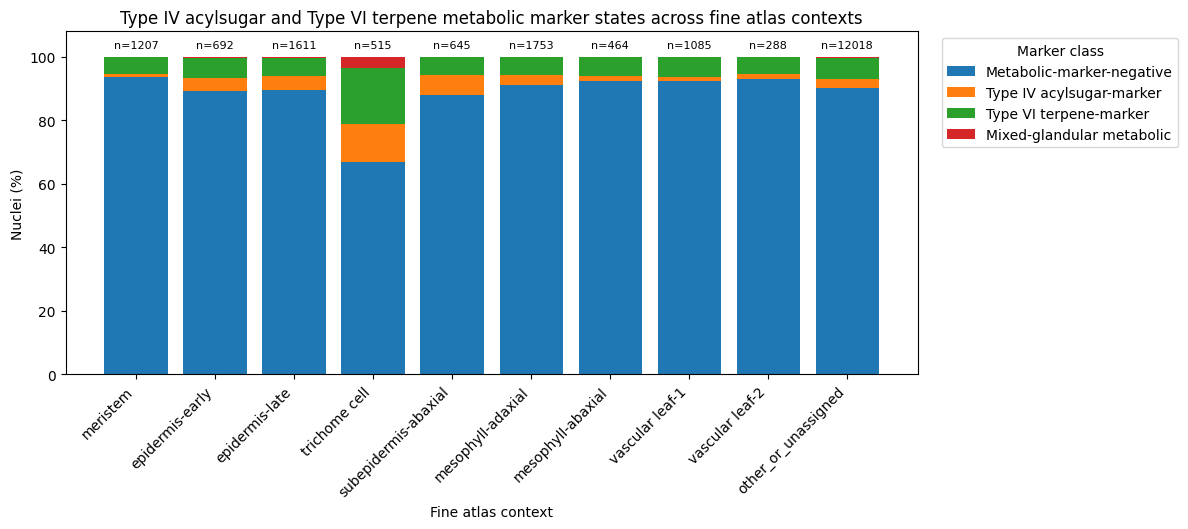

In [35]:
context_class_counts = class_df.groupby(["fine_focus_group", "marker_class"]).size().unstack(fill_value=0).reindex(fine_context_order)
for marker_class in marker_class_order:
    if marker_class not in context_class_counts.columns:
        context_class_counts[marker_class] = 0
context_class_counts = context_class_counts[marker_class_order]
context_class_percent = context_class_counts.div(context_class_counts.sum(axis=1), axis=0) * 100
context_class_counts.to_csv(TABLE_DIR / "typeIV_typeVI_marker_class_counts_by_fine_context.csv")
context_class_percent.to_csv(TABLE_DIR / "typeIV_typeVI_marker_class_percent_by_fine_context.csv")
display(context_class_counts); display(context_class_percent.round(2))

fig, ax = plt.subplots(figsize=(12, 5.4))
x = np.arange(context_class_percent.shape[0]); bottom = np.zeros(context_class_percent.shape[0])
for marker_class in marker_class_order:
    values = context_class_percent[marker_class].values
    ax.bar(x, values, bottom=bottom, label=marker_class); bottom += values
for i, n in enumerate(context_class_counts.sum(axis=1).values):
    ax.text(i, 102, f"n={int(n)}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(context_class_percent.index, rotation=45, ha="right")
ax.set_ylabel("Nuclei (%)"); ax.set_xlabel("Fine atlas context")
ax.set_title("Type IV acylsugar and Type VI terpene metabolic marker states across fine atlas contexts")
ax.set_ylim(0, 108); ax.legend(title="Marker class", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); save_current_figure("Fig3_typeIV_typeVI_metabolic_marker_states_by_fine_context.png"); plt.show()

---
## 10 — Marker-state enrichment statistics

Fisher exact tests (one-sided, BH-FDR corrected) confirm whether each
metabolic marker class is significantly over-represented in trichome nuclei
relative to all other nuclei in the atlas.

> **Interpretation note:** Odds ratios should be interpreted cautiously for
> genes with fewer than 10 detected nuclei in the trichome group. In sparse
> snRNA-seq data, small absolute counts can inflate odds ratio estimates even
> when the Fisher p-value is significant. The `low_count_flag` column marks
> genes where `group_positive < 10`.


In [36]:
state_tests = []
for marker_class in ["Type IV acylsugar-marker", "Type VI terpene-marker", "Mixed-glandular metabolic"]:
    feature_mask = class_df["marker_class"].astype(str).eq(marker_class)
    state_tests.append(fisher_enrichment(trichome_mask.values, feature_mask.values, "trichome cell", marker_class))
metabolic_state_enrichment = pd.DataFrame(state_tests)
metabolic_state_enrichment["padj_BH"] = bh_fdr(metabolic_state_enrichment["pvalue"])
metabolic_state_enrichment["low_count_flag"] = metabolic_state_enrichment["group_positive"] < 10
metabolic_state_enrichment.to_csv(TABLE_DIR / "metabolic_marker_state_enrichment_in_trichome_nuclei.csv", index=False)
display(metabolic_state_enrichment)


,group,feature,group_positive,group_negative,outside_positive,outside_negative,group_fraction_positive,outside_fraction_positive,odds_ratio,pvalue,padj_BH,low_count_flag
0,trichome cell,Type IV acylsugar-marker,61,454,573,19190,0.118447,0.028994,4.499812,2.642480e-19,7.927439e-19,False
1,trichome cell,Type VI terpene-marker,91,424,1227,18536,0.176699,0.062086,3.242254,1.351434e-18,2.027152e-18,False
2,trichome cell,Mixed-glandular metabolic,18,497,71,19692,0.034951,0.003593,10.044946,8.242605e-12,8.242605e-12,False


Metabolic marker classes are significantly enriched in trichome nuclei (Fisher exact, BH-FDR corrected p < 10⁻¹¹ to 10⁻¹⁸), confirming that sparse marker detection is biologically located rather than randomly distributed. However, the sensitivity analysis demonstrates that Type IV classification in particular is driven by single-gene detection at threshold T1, and the odds ratio enrichment should be interpreted in that context.

---
## 11 — Figure 4 (synthesis): Developmental and specificity context of glandular marker programs

This figure replaces the original single-panel synthesis heatmap with two
complementary panels that together tell a clearer story.

**Panel A — Developmental progression**
Rows span the epidermis-to-trichome developmental axis plus the trichome
metabolic marker classes. This tests whether the metabolic marker states
sit at the expected position in the developmental hierarchy.

**Panel B — Lineage specificity**
Rows compare trichome metabolic classes against two unrelated lineages
(mesophyll-adaxial and vascular leaf-1) as tissue-level negative controls.
If Type IV-like and Type VI-like signal is trichome-specific, it should be
absent from these tissues.

**Colour scale:** Mean expression z-scored per gene across all rows shown
in each panel. **n shown for every row** so the reader can judge group size.

> Note: z-scoring is performed across all rows within each panel separately,
> so the two panels cannot be directly compared by colour alone.


C:\Users\fforn\AppData\Local\Temp\ipykernel_18436\1426569412.py:139: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 1])
C:\Users\fforn\AppData\Local\Temp\ipykernel_18436\1426569412.py:139: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.91, 1])


Saved: figures\Fig4_developmental_and_specificity_context_heatmap.png


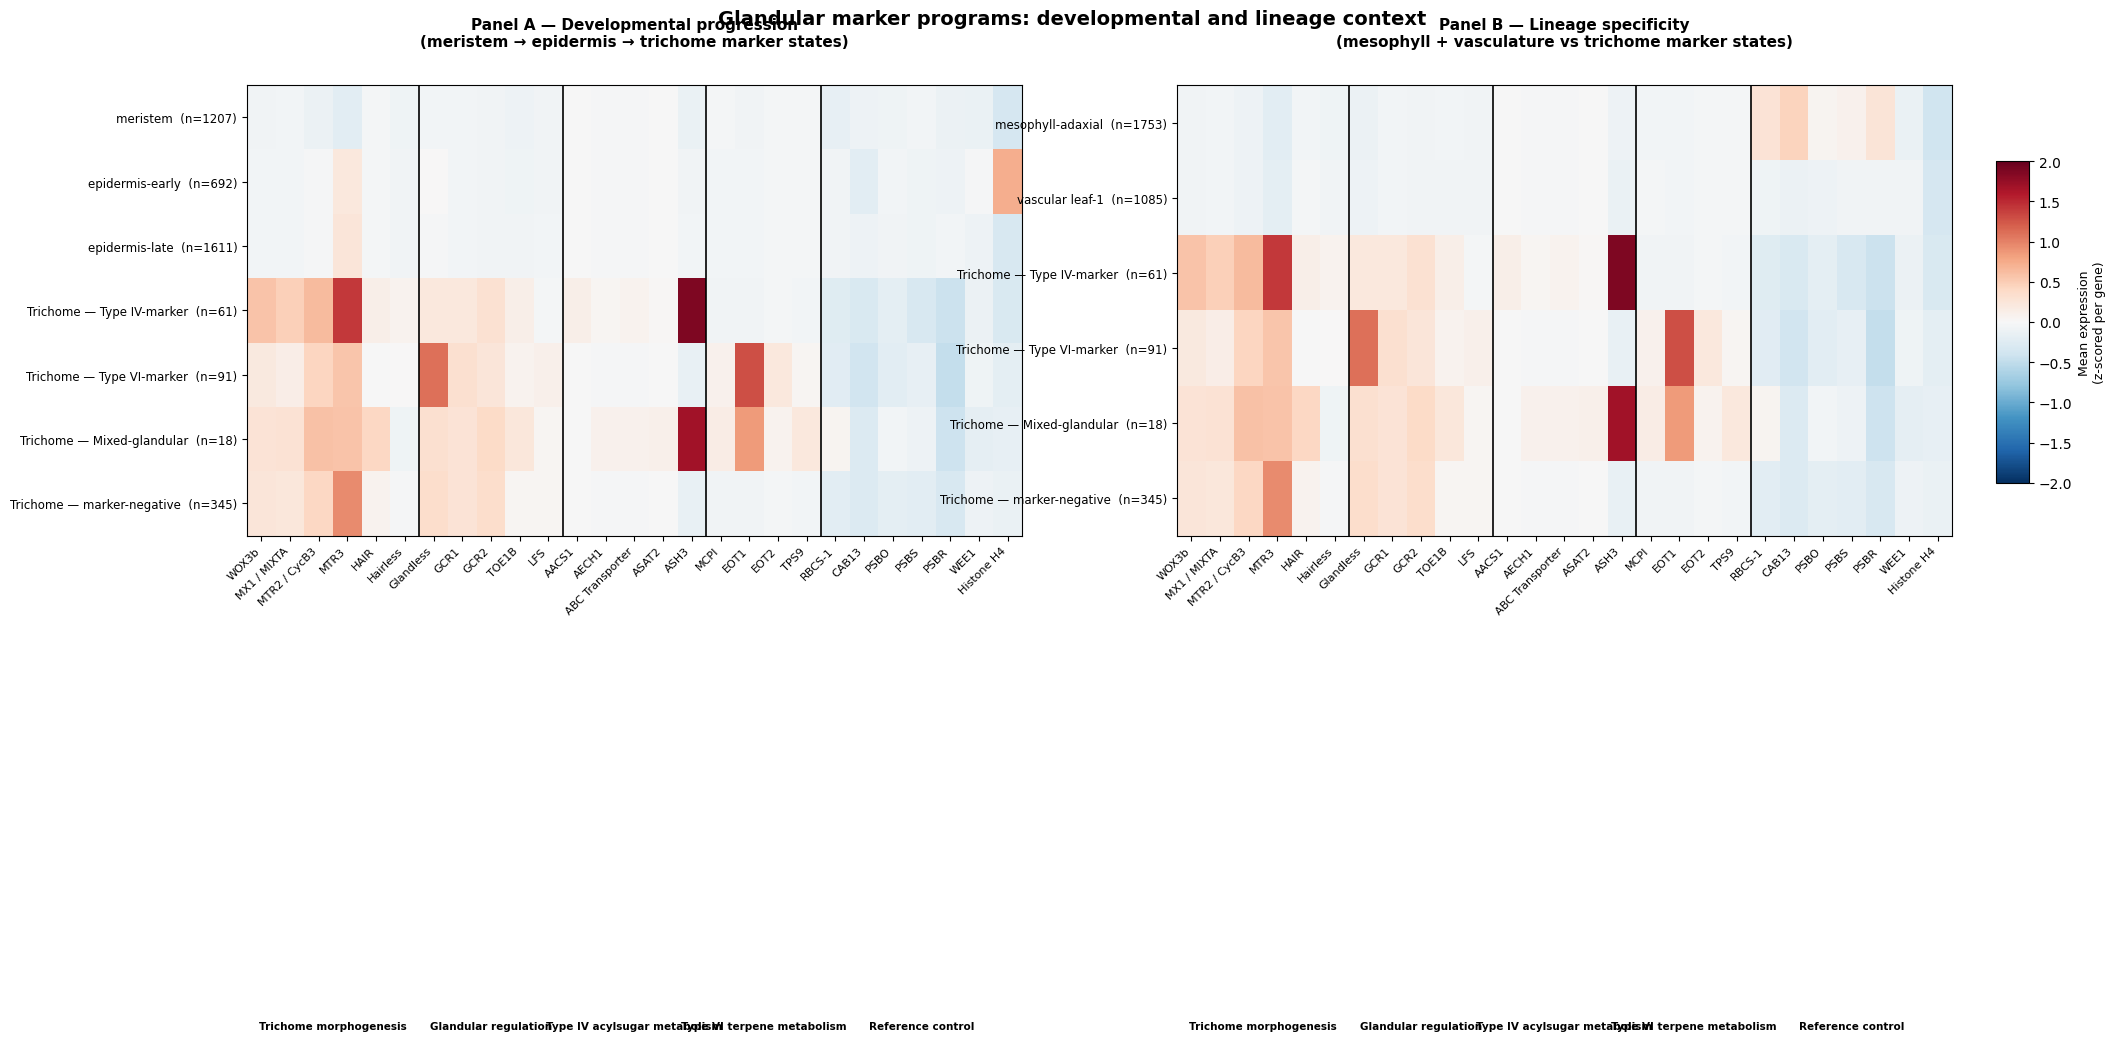

In [37]:
# ── New two-panel Fig 4 (developmental + specificity context) ────────────────

synthesis_module_order_f4 = [
    "trichome_morphogenesis",
    "glandular_regulation",
    "typeIV_acylsugar_metabolism",
    "typeVI_terpene_metabolism",
    "reference_control",
]
synthesis_markers_f4 = curated_markers[
    curated_markers["module"].astype(str).isin(synthesis_module_order_f4)
].copy()
synthesis_markers_f4["module"] = pd.Categorical(
    synthesis_markers_f4["module"].astype(str),
    categories=synthesis_module_order_f4, ordered=True
)
synthesis_markers_f4 = synthesis_markers_f4.sort_values(["module", "gene_order", "display_name"])
s_ids    = synthesis_markers_f4["atlas_id"].tolist()
s_labels = synthesis_markers_f4["display_name"].tolist()

X_synth = get_expression_df(adata, s_ids, layer=analysis_layer)
X_synth_z = zscore_columns(X_synth).clip(-2, 2)

# ── build per-group mean z-score matrices ─────────────────────────────────────
trichome_marker_rows = [
    "Type IV acylsugar-marker",
    "Type VI terpene-marker",
    "Mixed-glandular metabolic",
    "Metabolic-marker-negative",
]
row_label_map_f4 = {
    "Type IV acylsugar-marker":    "Trichome — Type IV-marker",
    "Type VI terpene-marker":      "Trichome — Type VI-marker",
    "Mixed-glandular metabolic":   "Trichome — Mixed-glandular",
    "Metabolic-marker-negative":   "Trichome — marker-negative",
}

def mean_z_for_context(ctx_name):
    mask = adata.obs["fine_focus_group"].astype(str).eq(ctx_name)
    n = int(mask.sum())
    if n == 0:
        return pd.Series(np.nan, index=s_ids), n
    return X_synth_z.loc[mask].mean(), n

def mean_z_for_tri_class(cls_name):
    tri_mask_local = class_df["fine_focus_group"].eq("trichome cell")
    cls_mask = class_df["marker_class"].astype(str).eq(cls_name)
    combined = tri_mask_local & cls_mask
    n = int(combined.sum())
    if n == 0:
        return pd.Series(np.nan, index=s_ids), n
    return X_synth_z.loc[combined[combined].index].mean(), n

# Panel A: developmental rows
panel_a_contexts = ["meristem", "epidermis-early", "epidermis-late"]
panel_a_rows = []
panel_a_labels = []
for ctx in panel_a_contexts:
    vals, n = mean_z_for_context(ctx)
    panel_a_rows.append(vals[s_ids].values)
    panel_a_labels.append(f"{ctx}  (n={n})")
for cls in trichome_marker_rows:
    vals, n = mean_z_for_tri_class(cls)
    panel_a_rows.append(vals[s_ids].values)
    panel_a_labels.append(f"{row_label_map_f4[cls]}  (n={n})")

mat_a = pd.DataFrame(panel_a_rows, columns=s_labels, index=panel_a_labels)

# Panel B: specificity rows
panel_b_contexts = ["mesophyll-adaxial", "vascular leaf-1"]
panel_b_rows = []
panel_b_labels = []
for ctx in panel_b_contexts:
    vals, n = mean_z_for_context(ctx)
    panel_b_rows.append(vals[s_ids].values)
    panel_b_labels.append(f"{ctx}  (n={n})")
for cls in trichome_marker_rows:
    vals, n = mean_z_for_tri_class(cls)
    panel_b_rows.append(vals[s_ids].values)
    panel_b_labels.append(f"{row_label_map_f4[cls]}  (n={n})")

mat_b = pd.DataFrame(panel_b_rows, columns=s_labels, index=panel_b_labels)

mat_a.to_csv(TABLE_DIR / "fig4a_developmental_context_heatmap.csv")
mat_b.to_csv(TABLE_DIR / "fig4b_specificity_context_heatmap.csv")

# ── module boundary positions ──────────────────────────────────────────────
module_sizes_f4 = (
    synthesis_markers_f4.groupby("module", observed=True)
    .size()
    .reindex(synthesis_module_order_f4)
)

def draw_heatmap_panel(ax, mat, title, module_sizes, module_labels_map):
    im = ax.imshow(mat.values, aspect="auto", cmap="RdBu_r", vmin=-2, vmax=2)
    ax.set_yticks(np.arange(mat.shape[0]))
    ax.set_yticklabels(mat.index, fontsize=8.5)
    ax.set_xticks(np.arange(mat.shape[1]))
    ax.set_xticklabels(mat.columns, rotation=45, ha="right", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=28)
    # module boundaries + labels
    start = 0
    for mod_id, size in module_sizes.items():
        size = int(size)
        if start > 0:
            ax.axvline(start - 0.5, color="black", linewidth=1.2)
        mid = start + (size - 1) / 2
        ax.text(mid, -1.1, module_labels_map.get(mod_id, mod_id),
                ha="center", va="bottom", fontsize=7.5, fontweight="bold",
                transform=ax.get_xaxis_transform())
        start += size
    return im

fig, axes = plt.subplots(1, 2, figsize=(22, max(4.5, 0.55 * max(len(mat_a), len(mat_b)) + 2)))

im = draw_heatmap_panel(axes[0], mat_a,
    "Panel A — Developmental progression\n(meristem → epidermis → trichome marker states)",
    module_sizes_f4, MODULE_LABELS)

draw_heatmap_panel(axes[1], mat_b,
    "Panel B — Lineage specificity\n(mesophyll + vasculature vs trichome marker states)",
    module_sizes_f4, MODULE_LABELS)

# shared colourbar
cbar_ax = fig.add_axes([0.92, 0.2, 0.015, 0.55])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.set_label("Mean expression\n(z-scored per gene)", fontsize=9)

fig.suptitle(
    "Glandular marker programs: developmental and lineage context",
    fontsize=14, fontweight="bold", y=1.01
)

# separator between panels
axes[0].annotate("", xy=(1.04, 0.5), xytext=(1.04, 0.5),
                 xycoords="axes fraction",
                 arrowprops=dict(arrowstyle="-", color="grey"))

plt.tight_layout(rect=[0, 0, 0.91, 1])
save_current_figure("Fig4_developmental_and_specificity_context_heatmap.png")
plt.show()


---
## 12 — Spatial context: ggPlantMap export tables

This cell exports ROI-level module and gene values for the ggPlantMap R scripts.

The module rows are used for the main ggPlantMap figure. Gene rows are also exported for optional key-gene maps; these are useful if time allows, but the GitHub story does not depend on them.

In [38]:
# ============================================================
# Export ggPlantMap module and gene values from restored modules
# ============================================================

GGPLANTMAP_DIR = Path("data")
GGPLANTMAP_DIR.mkdir(exist_ok=True)

roi_to_fine_group = {
    "Meristem": "meristem",
    "MeristemEpidermis": "epidermis-early",
    "LeafEpidermis": "epidermis-late",
    "Trichome": "trichome cell",
    "Subepidermis": "subepidermis-abaxial",
    "AdaxialMesophyll": "mesophyll-adaxial",
    "AbaxialMesophyll": "mesophyll-abaxial",
    "Vasculature": "vascular leaf-1",
    "LeafMargin": "other_or_unassigned",
    "RibZone": "other_or_unassigned",
    "OC": "meristem",
}

# ------------------------------------------------------------------
# Module-level values
# ------------------------------------------------------------------

module_scores_file = TABLE_DIR / "final_module_scores_by_fine_focus_group.csv"

if not module_scores_file.exists():
    raise FileNotFoundError(
        f"Missing {module_scores_file}. Run the module score section first."
    )

module_scores = pd.read_csv(module_scores_file)

module_score_columns = {
    "epidermal_identity": "Epidermal identity",
    "trichome_morphogenesis": "Trichome morphogenesis",
    "glandular_regulation": "Glandular regulation",
    "typeIV_acylsugar_metabolism": "Type IV acylsugar metabolism",
    "typeVI_terpene_metabolism": "Type VI terpene metabolism",
    "reference_control": "Reference control",
}

missing_cols = [
    col for col in module_score_columns.values()
    if col not in module_scores.columns
]

if missing_cols:
    raise ValueError(
        "Missing expected module score columns:\n"
        + "\n".join(missing_cols)
        + "\n\nAvailable columns:\n"
        + "\n".join(module_scores.columns)
    )

rows = []

for roi_name, fine_group in roi_to_fine_group.items():
    match = module_scores[module_scores["fine_focus_group"].astype(str).eq(fine_group)]

    for module_id, module_label in module_score_columns.items():
        if match.empty:
            value = np.nan
            note = f"No matching fine_focus_group: {fine_group}"
        else:
            value = float(match[module_label].iloc[0])
            note = None

        rows.append({
            "ROI.name": roi_name,
            "feature": f"{module_id}_score",
            "feature_label": module_label,
            "feature_type": "module",
            "module": module_id,
            "value_raw": value,
            "value_z": value,
            "mapping_note": note,
            "key_gene": False,
        })

# ------------------------------------------------------------------
# Gene-level values for optional ggPlantMap key-gene panels
# ------------------------------------------------------------------

mapped_genes = curated_markers.dropna(subset=["atlas_id"]).copy()
mapped_genes = mapped_genes.drop_duplicates(subset=["display_name", "atlas_id", "module"])

# Mean expression per fine context for all mapped curated genes.
gene_ids = mapped_genes["atlas_id"].dropna().drop_duplicates().tolist()
expr_for_map = get_expression_df(adata, gene_ids, layer=analysis_layer)
expr_for_map["fine_focus_group"] = adata.obs["fine_focus_group"].astype(str).values

gene_mean_by_fine = (
    expr_for_map
    .groupby("fine_focus_group")[gene_ids]
    .mean()
)

# Z-score each gene across fine contexts so maps are comparable within gene.
gene_z_by_fine = gene_mean_by_fine.copy()
gene_z_by_fine = gene_z_by_fine.sub(gene_z_by_fine.mean(axis=0), axis=1)
gene_z_by_fine = gene_z_by_fine.div(gene_z_by_fine.std(axis=0).replace(0, np.nan), axis=1)
gene_z_by_fine = gene_z_by_fine.fillna(0)

key_gene_aliases = {
    "Wo": ["Wo", "WOOLLY / Wo"],
    "MTR3": ["MTR3", "SlMTR3"],
    "TOE1B": ["TOE1B", "SlTOE1B"],
    "ABC Transporter": ["ABC Transporter", "ABC transporter"],
    "ASH3": ["ASH3", "SlASH3"],
    "EOT1": ["EOT1", "SlEOT1", "ETO1"],
    "MCPI": ["MCPI", "MCP1"],
    "RBCS-1": ["RBCS-1", "RBC1", "RbcS-T"],
    "PSBO": ["PSBO"],
    "Histone H4": ["Histone H4", "Histone 4", "HISTONE H4"],
}

key_gene_names = set()
for aliases in key_gene_aliases.values():
    for alias in aliases:
        key_gene_names.add(alias)

for roi_name, fine_group in roi_to_fine_group.items():
    for _, row in mapped_genes.sort_values(["module", "gene_order", "display_name"]).iterrows():
        gene_id = row["atlas_id"]
        display_name = row["display_name"]

        if fine_group in gene_mean_by_fine.index and gene_id in gene_mean_by_fine.columns:
            raw_value = float(gene_mean_by_fine.loc[fine_group, gene_id])
            z_value = float(gene_z_by_fine.loc[fine_group, gene_id])
            note = None
        else:
            raw_value = np.nan
            z_value = np.nan
            note = f"No matching fine_focus_group or gene for {fine_group} / {gene_id}"

        rows.append({
            "ROI.name": roi_name,
            "feature": display_name,
            "feature_label": display_name,
            "feature_type": "gene",
            "module": row["module"],
            "value_raw": raw_value,
            "value_z": z_value,
            "mapping_note": note,
            "key_gene": display_name in key_gene_names,
        })

ggplantmap_values = pd.DataFrame(rows)

out_name = "ggplantmap_module_and_gene_values.csv"
root_out = Path(out_name)
data_out = GGPLANTMAP_DIR / out_name

ggplantmap_values.to_csv(root_out, index=False)
ggplantmap_values.to_csv(data_out, index=False)

module_gene_lookup = (
    mapped_genes
    .sort_values(["module", "gene_order", "display_name"])
    [["module", "module_label", "display_name", "gene_role", "function_summary", "reference_label", "atlas_id", "solyc_id"]]
    .rename(columns={"display_name": "Gene Name", "module": "module_id", "module_label": "module_name"})
)

module_gene_lookup.to_csv("ggplantmap_module_gene_lookup.csv", index=False)
module_gene_lookup.to_csv(GGPLANTMAP_DIR / "ggplantmap_module_gene_lookup.csv", index=False)

key_gene_lookup = ggplantmap_values.query("feature_type == 'gene' and key_gene == True")[[
    "feature", "feature_label", "module", "ROI.name", "value_raw", "value_z"
]]
key_gene_lookup.to_csv("ggplantmap_key_gene_values.csv", index=False)
key_gene_lookup.to_csv(GGPLANTMAP_DIR / "ggplantmap_key_gene_values.csv", index=False)

print("Saved:")
print(root_out.resolve())
print(data_out.resolve())
print("Rows exported:", ggplantmap_values.shape[0])
print("Feature types:")
display(ggplantmap_values["feature_type"].value_counts().rename_axis("feature_type").reset_index(name="n_rows"))
print("Key genes found:")
display(sorted(ggplantmap_values.loc[ggplantmap_values["key_gene"], "feature"].unique()))

Saved:
C:\Users\fforn\tomato_atlas\GitHub\Final666\ggplantmap_module_and_gene_values.csv
C:\Users\fforn\tomato_atlas\GitHub\Final666\data\ggplantmap_module_and_gene_values.csv
Rows exported: 418
Feature types:


,feature_type,n_rows
0,gene,352
1,module,66


Key genes found:


['ABC Transporter',
 'ASH3',
 'EOT1',
 'Histone H4',
 'MCPI',
 'MTR3',
 'PSBO',
 'RBCS-1',
 'TOE1B',
 'Wo']

### Shoot-apex ROI anatomy guide

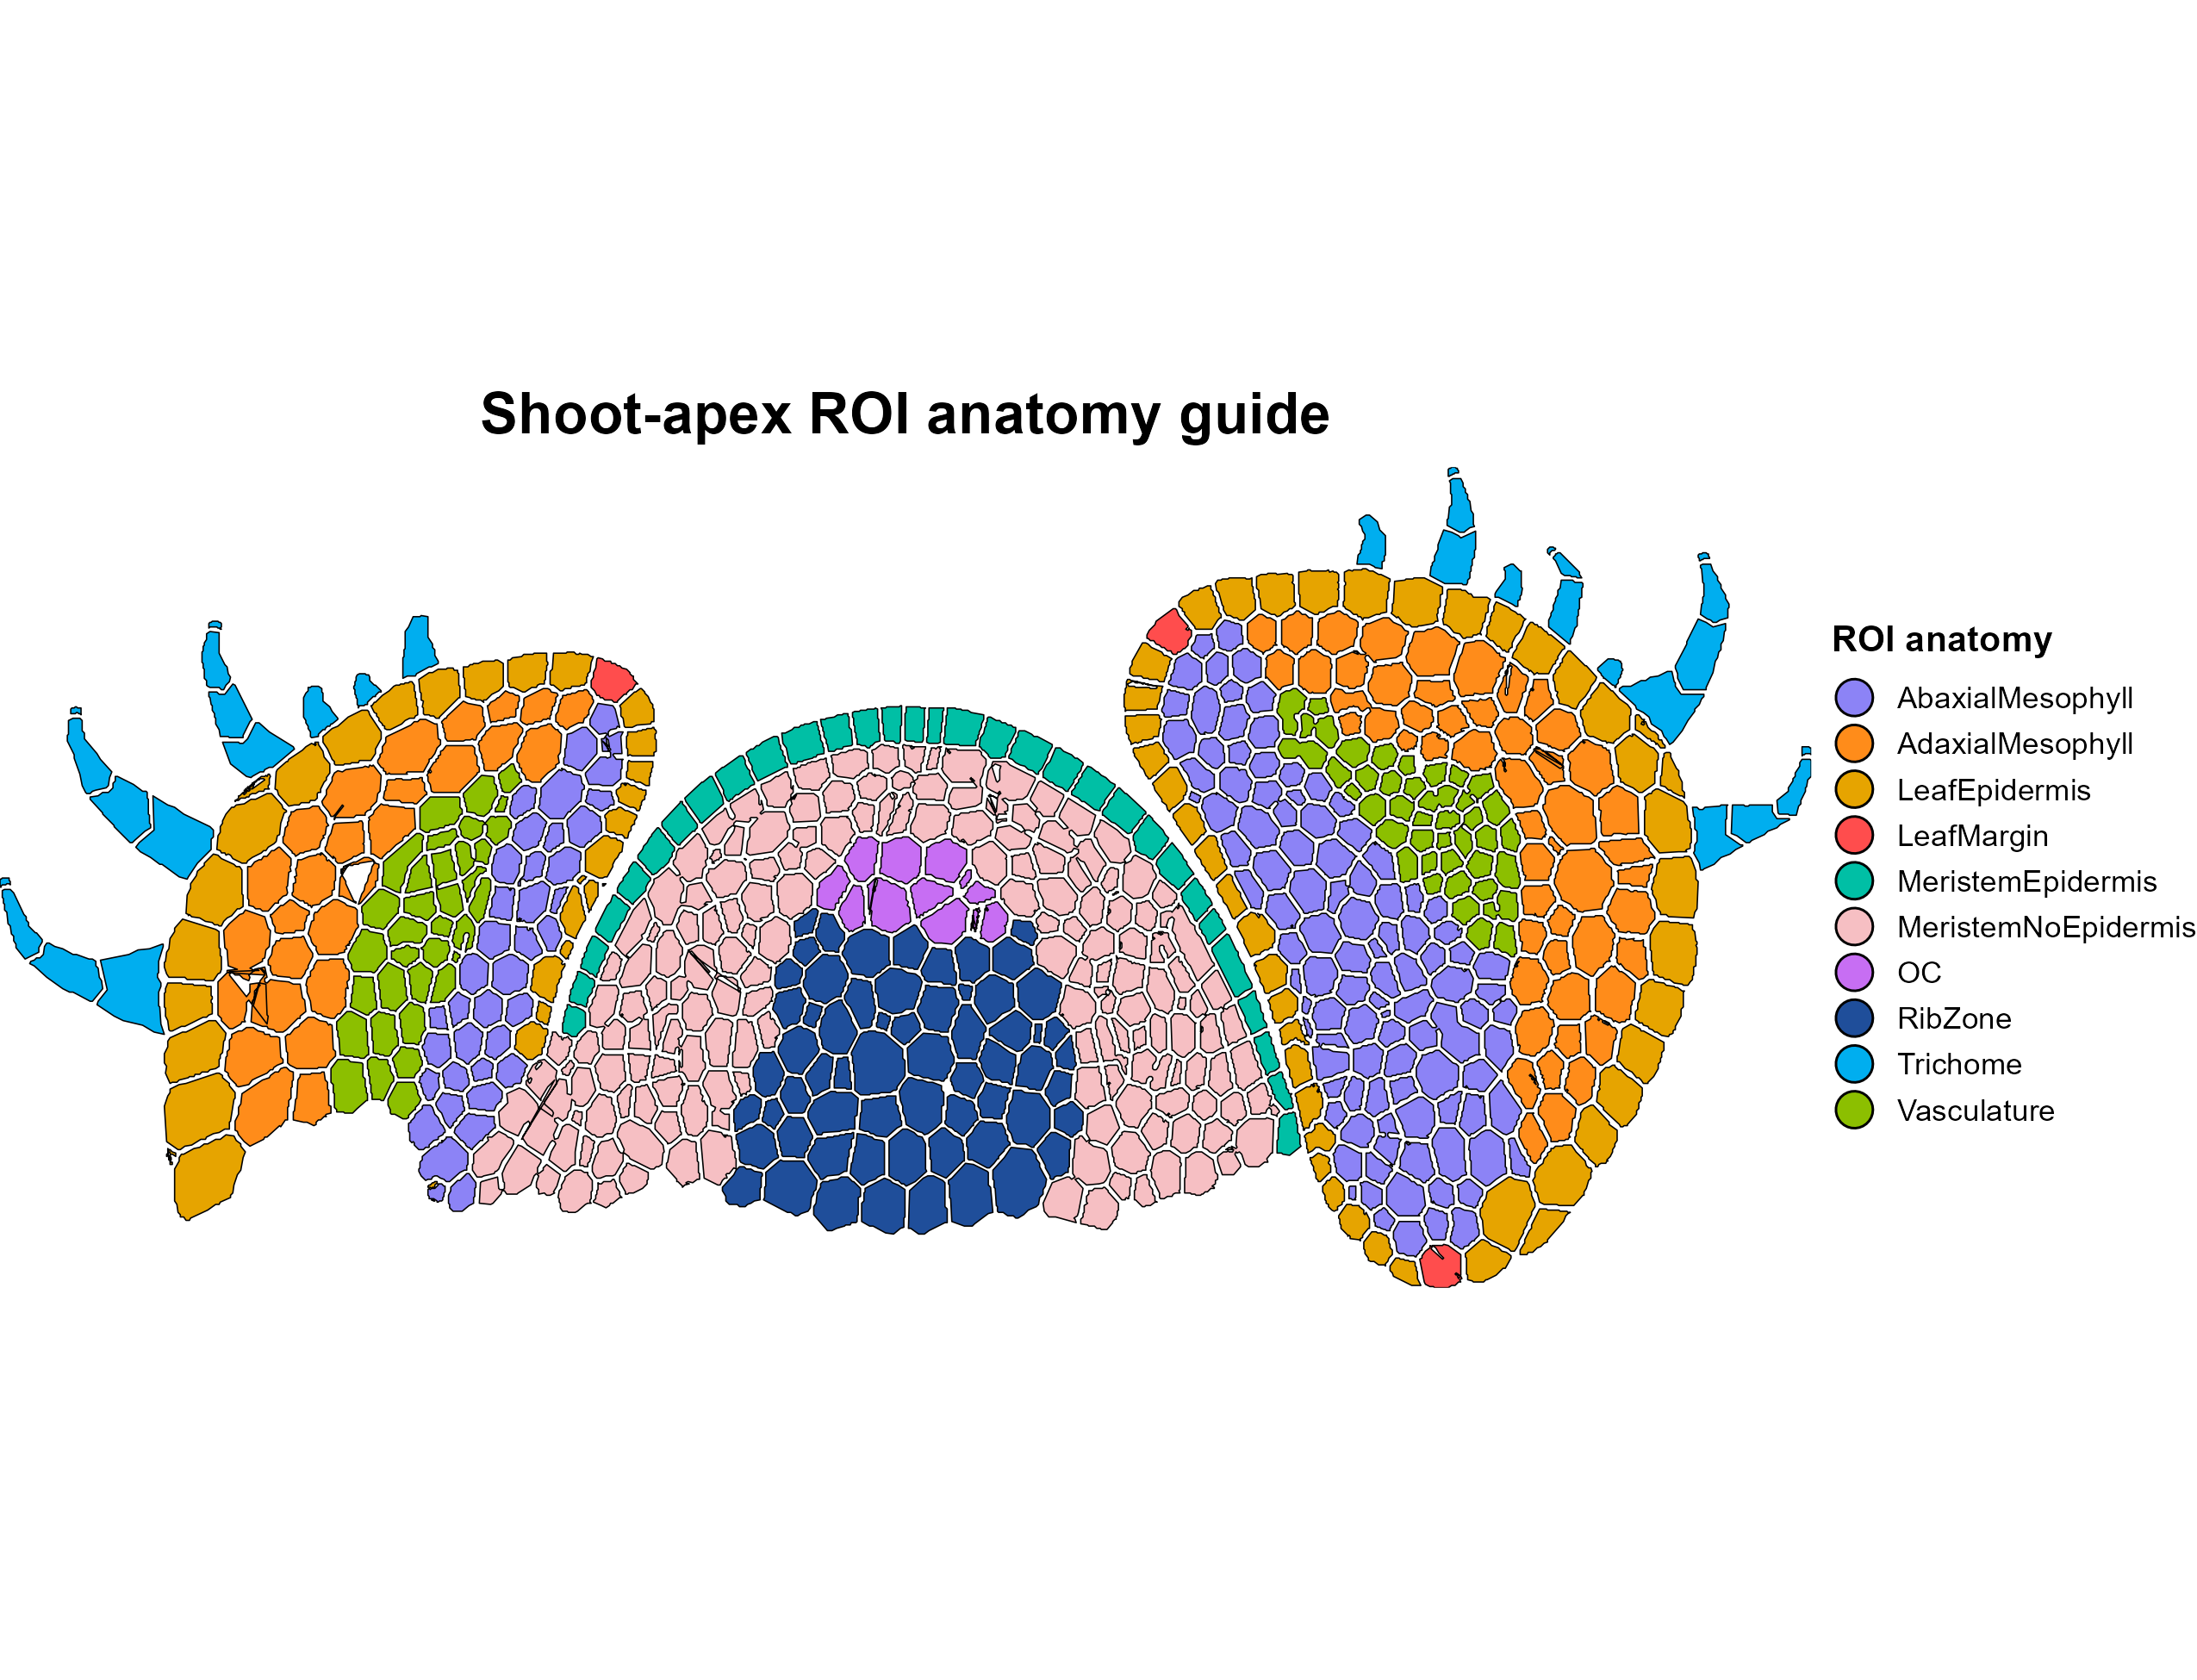

### Developmental and glandular metabolism module overview

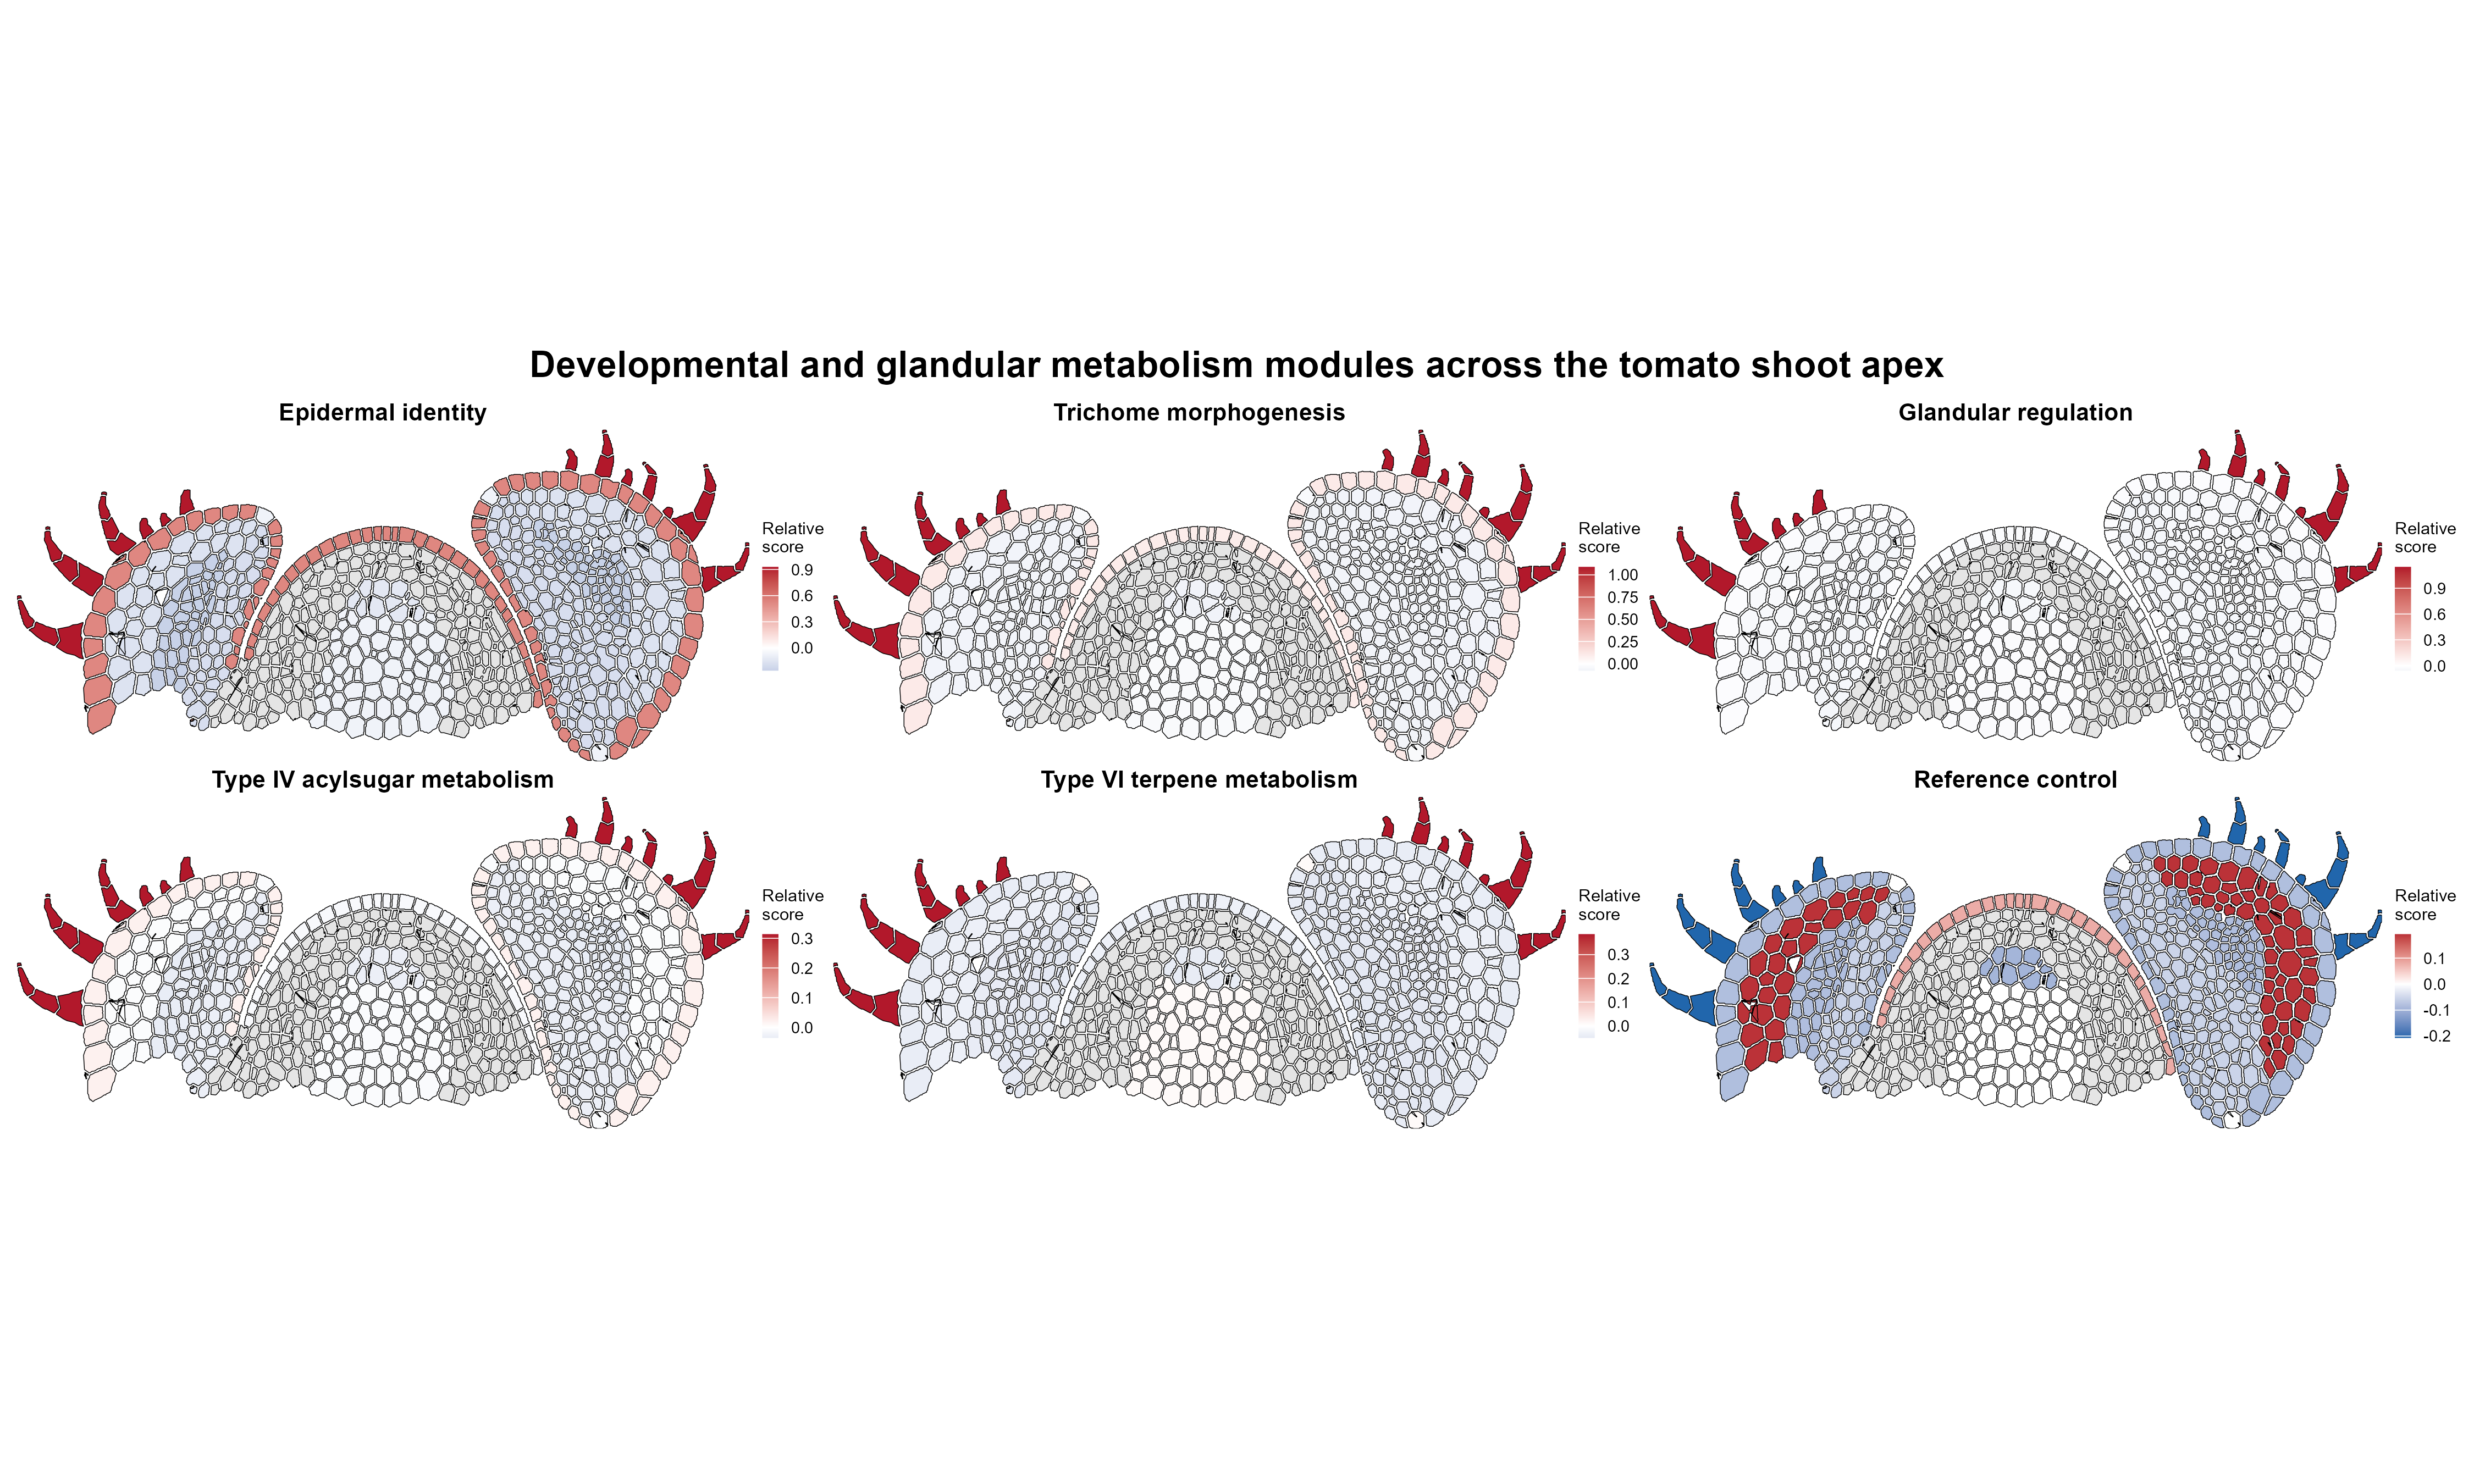

In [39]:
from PIL import Image as PILImage
pre_generated_figures = {"Shoot-apex ROI anatomy guide": FIG_DIR / "Fig2_shoot_apex_roi_anatomy_guide.png", "Developmental and glandular metabolism module overview": FIG_DIR / "Fig1_developmental_module_overview.png"}
def display_with_white_background(path):
    image = PILImage.open(path).convert("RGBA")
    background = PILImage.new("RGBA", image.size, "WHITE")
    background.alpha_composite(image)
    output = path.with_name(path.stem + "_white_bg.png")
    background.convert("RGB").save(output)
    return output
for title, path in pre_generated_figures.items():
    display(Markdown(f"### {title}"))
    if path.exists(): display(Image(filename=str(display_with_white_background(path)), width=1400))
    else: print(f"Figure not found: {path}")

> **Optional next improvement:** If time allows, use the exported `ggplantmap_key_gene_values.csv` table to create small ggPlantMap panels for representative genes such as Wo, MTR3, TOE1B, ABC Transporter, ASH3, EOT1, MCPI, RBCS-1, PSBO, and Histone H4. This would support the module maps with concrete marker-gene examples.

---
## 13 — Interpretation and limitations

### What the atlas supports

This analysis confirms that the Tian et al. (2020) shoot-apex snRNA-seq atlas
captures **trichome developmental identity** robustly. The trichome morphogenesis
module (WOX3b, MX1/MIXTA, HAIR, MTR3) and glandular regulation module
(Glandless, GCR1, GCR2, TOE1B, LFS) are both strongly and specifically enriched
in atlas-defined trichome nuclei. Epidermal identity co-enriches, consistent with
trichomes arising from the L1 epidermal layer.

Within trichome nuclei, **partial metabolic marker programs** are detectable:
Type IV acylsugar and Type VI terpene metabolism markers each mark a distinct
minority subpopulation. The two-panel synthesis figure (Fig 4) shows that these
signals are (A) positioned at the expected point in the epidermis-to-trichome
developmental hierarchy and (B) largely absent from unrelated lineages
(mesophyll, vasculature), supporting their specificity.

### What the atlas does not support

The atlas **does not** resolve mature Type IV vs Type VI trichome subtypes cleanly.
Most trichome nuclei (~67%) are metabolic-marker-negative. Two non-exclusive
explanations account for this:

1. **Early developmental stage:** The sampled tissue (shoot apex, P0–P3 primordia)
   precedes mature glandular trichome development in cultivated tomato (M82).
2. **Nuclear capture bias:** snRNA-seq systematically underrepresents cytoplasmic
   transcripts, including metabolic enzyme mRNAs (Ding et al. 2020). Acylsugar
   transferases and terpene synthases are translated in the cytoplasm; their
   nuclear transcript levels are expected to be low relative to whole-cell protocols.

The sensitivity analysis (Section 8c) shows how classification proportions
change across detection thresholds, providing an honest assessment of signal robustness.

### Classification scheme

The four metabolic marker states (marker-negative, Type IV-like, Type VI-like,
mixed) are **rule-based approximations**, not cluster-derived cell types.
They are useful for candidate prioritisation and developmental hypothesis generation,
but should not be treated as definitive trichome subtype annotations.

### ggPlantMap projections

The spatial figures are schematic hypothesis maps based on manually drawn ROIs
and atlas cluster averages. They are intended to visualise predictions for future
spatial transcriptomics validation, not to claim spatial resolution from this dataset.

### Next steps

- Apply the same marker-module framework to mature leaf trichome scRNA-seq datasets
  (e.g. Kim et al. 2022 or Bornowski et al. 2021) for mature-cell comparisons where
  cytoplasmic transcripts are captured and nuclear bias is absent.
- Use the atlas-derived developmental context as prior for pseudotime or trajectory
  analysis along the epidermis → trichome axis.
- Validate candidate regulatory genes (GCR1, GCR2, TOE1B) in functional trichome
  assays or CRISPR screens in tomato.
- Test spatial predictions from the ggPlantMap projections with future MERFISH or
  Slide-seq experiments on tomato shoot-apex sections.
